In [6]:
# ============================================================
# CELL 1 — SETUP
# Mount Drive, install packages, create directories, check GPU
# Run this FIRST at the start of every Colab session.
#
# FIXES:
#   - Removed `from dotenv import load_dotenv` (not installed on Colab)
#   - Removed lightgbm from pip install (unused in pipeline)
#   - CV_API_KEY read directly as a plain string — paste it below
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install praat-parselmouth noisereduce soundfile transformers torchaudio -q

import os, io, time, tarfile, requests, warnings, joblib
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import librosa, soundfile as sf, noisereduce as nr
from tqdm.notebook import tqdm
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, accuracy_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (StratifiedKFold, StratifiedShuffleSplit,
                                      RandomizedSearchCV, GroupShuffleSplit,
                                      GridSearchCV)
from scipy import stats
from scipy.stats import loguniform
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────
PROJECT_ROOT = "/content/drive/MyDrive/team_databaes"
OUTPUT_DIR   = f"{PROJECT_ROOT}/outputs"
ENSEMBLE_DIR = f"{OUTPUT_DIR}/ensemble"
EMBED_DIR    = f"{PROJECT_ROOT}/data/embeddings"
TARGET_SR    = 16000
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

# ── ⚠️  PASTE YOUR MOZILLA DATA COLLECTIVE API KEY HERE ───────
CV_API_KEY = "0a1770b3c333e1cc9175c75a74337695384ea6d42931e26a4adfab8bc05847c0"

# ── Create directories ────────────────────────────────────────
for d in ["outputs", "outputs/ensemble",
          "data/train/native", "data/train/non_native",
          "data/preprocessed/native", "data/preprocessed/non_native",
          "data/embeddings",
          "data/segments/native", "data/segments/non_native",
          "data/augmented/native", "data/augmented/non_native"]:
    os.makedirs(f"{PROJECT_ROOT}/{d}", exist_ok=True)

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU")
    print("   Cell 6 (wav2vec2) and Cell 10 (LSTM) will be very slow on CPU.")

csv_path = f"{PROJECT_ROOT}/renan_dataset.csv"
if os.path.exists(csv_path):
    print(f"\n✅ renan_dataset.csv found ({len(pd.read_csv(csv_path))} rows)")
else:
    print(f"\n❌ renan_dataset.csv NOT found.")
    print(f"   Upload it to: {PROJECT_ROOT}/")

if CV_API_KEY == "YOUR_API_KEY_HERE":
    print("\n⚠️  CV_API_KEY not set — Cell 2 Part B (Common Voice) will be skipped.")
    print("   Get your key from: datacollective.mozillafoundation.org/profile/credentials")

print(f"\nProject root  : {PROJECT_ROOT}")
print(f"Ensemble dir  : {ENSEMBLE_DIR}")
print("✅ Setup complete.")

Mounted at /content/drive
Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB

✅ renan_dataset.csv found (178 rows)

Project root  : /content/drive/MyDrive/team_databaes
Ensemble dir  : /content/drive/MyDrive/team_databaes/outputs/ensemble
✅ Setup complete.


In [7]:
# ============================================================
# CELL 2 — DATA COLLECTION
# Part A: Download 160 Renan MP3s → Drive
# Part B: Fetch ~200 Common Voice native Arabic clips via API
# Part C: Build master manifest
# ⏭️  Resume-safe: skips already-downloaded files
#
# FIXES:
#   - BUG 1: Renan errors now printed (first 5) so you can see
#     exactly why downloads fail (e.g. wrong column names, bad URLs)
#   - BUG 2: clips_prefix detection — code used to BREAK as soon
#     as train.tsv was found, before any .mp3 appeared in stream.
#     Now continues scanning up to 500 more members after train.tsv
#     to find clips_prefix. Falls back to deriving prefix from the
#     first sampled path's directory structure if still None.
#   - BUG 3: KeyError on empty DataFrame — .drop(columns=...)
#     now uses errors='ignore' so it's safe when usable is empty.
# ============================================================

RENAN_CSV       = f"{PROJECT_ROOT}/renan_dataset.csv"
TRAIN_NATIVE    = f"{PROJECT_ROOT}/data/train/native"
TRAIN_NONNATIVE = f"{PROJECT_ROOT}/data/train/non_native"
MANIFEST_S2     = f"{OUTPUT_DIR}/stage2_manifest.csv"
CV_DATASET_ID   = "cmj8u3os6000tnxxb169x1zdc"
CV_API_URL      = f"https://datacollective.mozillafoundation.org/api/datasets/{CV_DATASET_ID}/download"
CV_NATIVE_N     = 200
CV_MIN_UPVOTES  = 2

if os.path.exists(MANIFEST_S2):
    manifest_df = pd.read_csv(MANIFEST_S2)
    usable = manifest_df[
        manifest_df["status"].isin(["downloaded", "already_exists", "extracted"]) &
        manifest_df["save_path"].notna()
    ]
    print(f"⏭️  Stage 2 already done — {len(usable)} usable files.")
    print(f"   Delete {MANIFEST_S2} to force re-run.")
else:
    # ═══════════════════════════════════════════════════════════
    # PART A — DOWNLOAD RENAN FILES
    # ═══════════════════════════════════════════════════════════
    print("=" * 55)
    print("  PART A — Downloading Renan Training Audio")
    print("=" * 55)

    df_renan = pd.read_csv(RENAN_CSV)

    # ── Print actual columns so we can catch mismatches early ──
    print(f"  CSV columns: {list(df_renan.columns)}")
    print(f"  CSV rows   : {len(df_renan)}")

    # ── Flexible column detection with clear error messages ────
    # nativity_status column
    if "nativity_status" in df_renan.columns:
        nativity_col = "nativity_status"
    else:
        candidates = [c for c in df_renan.columns if "nativ" in c.lower()]
        if candidates:
            nativity_col = candidates[0]
            print(f"  ⚠️  'nativity_status' not found — using '{nativity_col}'")
        else:
            raise ValueError(f"Cannot find nativity column. Columns: {list(df_renan.columns)}")

    # audio URL column
    if "audio_url" in df_renan.columns:
        url_col = "audio_url"
    else:
        candidates = [c for c in df_renan.columns if "url" in c.lower() or "link" in c.lower()]
        if candidates:
            url_col = candidates[0]
            print(f"  ⚠️  'audio_url' not found — using '{url_col}'")
        else:
            raise ValueError(f"Cannot find URL column. Columns: {list(df_renan.columns)}")

    # dialect/language column
    if "language" in df_renan.columns:
        dialect_col = "language"
    else:
        candidates = [c for c in df_renan.columns if "lang" in c.lower() or "dialect" in c.lower()]
        dialect_col = candidates[0] if candidates else df_renan.columns[0]
        print(f"  ⚠️  'language' not found — using '{dialect_col}' for dialect")

    # dp_id column
    if "dp_id" in df_renan.columns:
        id_col = "dp_id"
    else:
        candidates = [c for c in df_renan.columns if "id" in c.lower()]
        id_col = candidates[0] if candidates else df_renan.columns[0]
        print(f"  ⚠️  'dp_id' not found — using '{id_col}'")

    df_renan["label"]     = df_renan[nativity_col].map({"Native": 1, "Non-Native": 0})
    df_renan["_dp_id"]    = df_renan[id_col].astype(str)
    df_renan["_filename"] = df_renan["_dp_id"].apply(lambda x: f"dp_{x}.mp3")
    df_renan["_save_dir"] = df_renan["label"].map({1: TRAIN_NATIVE, 0: TRAIN_NONNATIVE})
    df_renan["_save_path"] = df_renan.apply(
        lambda r: os.path.join(r["_save_dir"], r["_filename"])
        if pd.notna(r["label"]) else None, axis=1)

    manifest_records = []
    error_samples    = []   # collect first 5 errors to print

    for _, row in tqdm(df_renan.iterrows(), total=len(df_renan), desc="Renan files"):
        dp_id = row["_dp_id"]
        sp    = row["_save_path"]

        if sp is None:
            manifest_records.append({
                "dp_id": dp_id, "status": "error",
                "source": "renan", "label": row["label"],
                "nativity": row[nativity_col], "dialect": row[dialect_col],
                "save_path": None,
                "error": f"Unknown nativity_status: {row[nativity_col]}",
            })
            continue

        if os.path.exists(sp):
            manifest_records.append({
                "dp_id": dp_id, "status": "already_exists",
                "source": "renan", "label": row["label"],
                "nativity": row[nativity_col], "dialect": row[dialect_col],
                "save_path": sp, "error": None,
            })
            continue

        try:
            r = requests.get(row[url_col], timeout=20)
            r.raise_for_status()
            with open(sp, "wb") as f:
                f.write(r.content)
            manifest_records.append({
                "dp_id": dp_id, "status": "downloaded",
                "source": "renan", "label": row["label"],
                "nativity": row[nativity_col], "dialect": row[dialect_col],
                "save_path": sp, "error": None,
            })
        except Exception as e:
            err_str = str(e)[:120]
            manifest_records.append({
                "dp_id": dp_id, "status": "error",
                "source": "renan", "label": row["label"],
                "nativity": row[nativity_col], "dialect": row[dialect_col],
                "save_path": None, "error": err_str,
            })
            if len(error_samples) < 5:
                error_samples.append(f"    dp_id={dp_id}: {err_str}")
        time.sleep(0.1)

    a_df = pd.DataFrame(manifest_records)
    n_ok  = (a_df["status"].isin(["downloaded", "already_exists"])).sum()
    n_err = (a_df["status"] == "error").sum()
    print(f"\nDownloaded: {(a_df['status']=='downloaded').sum()}, "
          f"Existing: {(a_df['status']=='already_exists').sum()}, "
          f"Failed: {n_err}")

    # ── Print actual errors so they are visible ────────────────
    if error_samples:
        print(f"\n  ⚠️  First {len(error_samples)} download errors:")
        for e in error_samples:
            print(e)
        if n_err > 5:
            print(f"  ... and {n_err - 5} more (see manifest for full list)")

    # ═══════════════════════════════════════════════════════════
    # PART B — MOZILLA COMMON VOICE VIA API (streaming tar)
    # ═══════════════════════════════════════════════════════════
    print("\n" + "=" * 55)
    print("  PART B — Common Voice Arabic via API")
    print("=" * 55)

    cv_records = []

    if CV_API_KEY == "YOUR_API_KEY_HERE":
        print("⚠️  CV_API_KEY not set — skipping Part B.")
        print("   Set your API key in Cell 1 and re-run.")
    else:
        class StreamingTarWrapper(io.RawIOBase):
            def __init__(self, response):
                self._iter = response.iter_content(chunk_size=256 * 1024)
                self._buf  = b""
                self.bytes_read = 0
            def readable(self):
                return True
            def readinto(self, b):
                while len(self._buf) < len(b):
                    try:
                        chunk = next(self._iter)
                        self._buf += chunk
                        self.bytes_read += len(chunk)
                    except StopIteration:
                        break
                n = min(len(b), len(self._buf))
                b[:n] = self._buf[:n]
                self._buf = self._buf[n:]
                return n

        # Get presigned URL
        print("Requesting presigned download URL...")
        try:
            resp = requests.post(CV_API_URL,
                headers={"Authorization": f"Bearer {CV_API_KEY}",
                         "Content-Type": "application/json"}, timeout=30)
            resp.raise_for_status()
            download_url = resp.json()["downloadUrl"]
            print("✅ Got presigned URL")
        except Exception as e:
            print(f"❌ API error: {e}")
            download_url = None

        df_filtered  = None
        df_sample    = None
        clips_prefix = None

        if download_url:
            print("Pass 1: Streaming archive to find train.tsv + clips_prefix...")
            s1 = requests.get(download_url, stream=True, timeout=120)
            s1.raise_for_status()
            w1 = StreamingTarWrapper(s1)

            tsv_found        = False
            post_tsv_scanned = 0
            MAX_POST_TSV     = 500   # scan up to 500 more members after TSV to find prefix

            with tarfile.open(fileobj=w1, mode="r|gz") as tar:
                for member in tar:
                    # Always try to detect clips_prefix from any .mp3
                    if (clips_prefix is None
                            and member.name.endswith(".mp3")
                            and "/ar/clips/" in member.name):
                        clips_prefix = member.name.rsplit("/ar/clips/", 1)[0] + "/ar/clips/"
                        print(f"  clips_prefix detected: {clips_prefix}")

                    # Read train.tsv
                    if not tsv_found and member.name.endswith("ar/train.tsv"):
                        f_obj  = tar.extractfile(member)
                        df_cv  = pd.read_csv(io.BytesIO(f_obj.read()), sep="\t")
                        df_cv["up_votes"]   = pd.to_numeric(df_cv["up_votes"],   errors="coerce").fillna(0)
                        df_cv["down_votes"] = pd.to_numeric(df_cv["down_votes"], errors="coerce").fillna(0)
                        df_filtered = df_cv[
                            (df_cv["up_votes"] >= CV_MIN_UPVOTES) &
                            (df_cv["down_votes"] == 0)
                        ].copy()

                        acol = ("accents" if "accents" in df_filtered.columns
                                else "accent" if "accent" in df_filtered.columns else None)
                        if acol is None:
                            df_filtered["accent"] = "unspecified"
                        else:
                            df_filtered["accent"] = (
                                df_filtered[acol].fillna("unspecified").replace("", "unspecified"))

                        groups = df_filtered["accent"].unique()
                        per    = max(1, CV_NATIVE_N // len(groups))
                        rem    = CV_NATIVE_N - per * len(groups)
                        parts  = []
                        for i, acc in enumerate(groups):
                            g = df_filtered[df_filtered["accent"] == acc]
                            parts.append(g.sample(
                                n=min(per + (1 if i < rem else 0), len(g)),
                                random_state=42))
                        df_sample = pd.concat(parts, ignore_index=True)
                        print(f"  Sampled {len(df_sample)} clips from {len(groups)} accent groups")
                        print(f"  Columns: {list(df_cv.columns)}")
                        tsv_found = True

                    # After TSV found, keep scanning for clips_prefix
                    if tsv_found and clips_prefix is not None:
                        break   # have both — done
                    if tsv_found:
                        post_tsv_scanned += 1
                        if post_tsv_scanned >= MAX_POST_TSV:
                            print(f"  ⚠️  clips_prefix not found after scanning "
                                  f"{MAX_POST_TSV} members post-TSV")
                            break
            s1.close()

            # ── Fallback: derive clips_prefix from archive path in TSV ──
            # If still None, reconstruct from first sampled path.
            # CV archives follow pattern: cv-corpus-XX.X-YYYY-MM-DD/ar/clips/
            if clips_prefix is None and df_sample is not None:
                first_path = df_sample["path"].iloc[0]
                # Try to find this path in a fresh scan of first few members
                print("  clips_prefix still None — trying to derive from archive structure...")
                try:
                    r_probe = requests.post(CV_API_URL,
                        headers={"Authorization": f"Bearer {CV_API_KEY}",
                                 "Content-Type": "application/json"}, timeout=30)
                    r_probe.raise_for_status()
                    dl_probe = r_probe.json()["downloadUrl"]
                    s_probe  = requests.get(dl_probe, stream=True, timeout=60)
                    s_probe.raise_for_status()
                    w_probe  = StreamingTarWrapper(s_probe)
                    scanned  = 0
                    with tarfile.open(fileobj=w_probe, mode="r|gz") as tar:
                        for member in tar:
                            if member.name.endswith(".mp3") and "/ar/clips/" in member.name:
                                clips_prefix = member.name.rsplit("/ar/clips/", 1)[0] + "/ar/clips/"
                                print(f"  clips_prefix found on probe: {clips_prefix}")
                                break
                            scanned += 1
                            if scanned > 2000:
                                break
                    s_probe.close()
                except Exception as e:
                    print(f"  Probe failed: {e}")

            # Last resort hardcoded fallback
            if clips_prefix is None:
                clips_prefix = "cv-corpus-24.0-2025-12-05/ar/clips/"
                print(f"  ⚠️  Using hardcoded fallback prefix: {clips_prefix}")
                print(f"  If 0 clips extract, the archive folder name has changed.")

            print(f"  Final clips_prefix: {clips_prefix}")

            if df_filtered is not None and df_sample is not None:
                accent_to_dialect = {
                    "saudi": "Arabic_SA", "gulf": "Arabic_QA", "egyptian": "Arabic_EG",
                    "levantine": "Arabic_LEV", "moroccan": "Arabic_MA",
                    "unspecified": "Arabic_MSA",
                }
                clips_needed = {}
                for idx, row in df_sample.iterrows():
                    slug     = str(row["accent"]).replace(" ", "_").lower()
                    out_path = os.path.join(TRAIN_NATIVE, f"cv_{slug}_{row['path']}")
                    tar_path = clips_prefix + row["path"]
                    clips_needed[tar_path] = {
                        "dp_id":     f"cv_{idx:06d}",
                        "out_path":  out_path,
                        "dialect":   accent_to_dialect.get(str(row["accent"]).lower(), "Arabic_MSA"),
                        "cv_accent": row["accent"],
                        "up_votes":  int(row["up_votes"]),
                    }

                # Print sample tar paths so mismatches are visible
                sample_paths = list(clips_needed.keys())[:3]
                print(f"\n  Sample expected tar paths:")
                for p in sample_paths:
                    print(f"    {p}")

                already_on_disk = {k: v for k, v in clips_needed.items()
                                   if os.path.exists(v["out_path"])}
                to_fetch        = {k: v for k, v in clips_needed.items()
                                   if not os.path.exists(v["out_path"])}

                for tar_path, info in already_on_disk.items():
                    cv_records.append({
                        "dp_id": info["dp_id"], "source": "mozilla_common_voice_24",
                        "label": 1, "nativity": "Native", "dialect": info["dialect"],
                        "save_path": info["out_path"], "status": "already_exists", "error": None,
                    })

                if to_fetch:
                    print(f"Pass 2: Extracting {len(to_fetch)} clips...")
                    try:
                        r2 = requests.post(CV_API_URL,
                            headers={"Authorization": f"Bearer {CV_API_KEY}",
                                     "Content-Type": "application/json"}, timeout=30)
                        r2.raise_for_status()
                        dl2 = r2.json()["downloadUrl"]
                    except Exception:
                        dl2 = download_url

                    s2        = requests.get(dl2, stream=True, timeout=120)
                    s2.raise_for_status()
                    w2        = StreamingTarWrapper(s2)
                    extracted = 0
                    pbar      = tqdm(total=len(to_fetch), desc="Extracting clips")

                    with tarfile.open(fileobj=w2, mode="r|gz") as tar:
                        for member in tar:
                            if member.name not in to_fetch:
                                continue
                            info  = to_fetch[member.name]
                            f_obj = tar.extractfile(member)
                            if f_obj:
                                try:
                                    with open(info["out_path"], "wb") as out_f:
                                        out_f.write(f_obj.read())
                                    cv_records.append({
                                        "dp_id": info["dp_id"],
                                        "source": "mozilla_common_voice_24",
                                        "label": 1, "nativity": "Native",
                                        "dialect": info["dialect"],
                                        "save_path": info["out_path"],
                                        "status": "extracted", "error": None,
                                    })
                                    extracted += 1
                                except Exception as e:
                                    cv_records.append({
                                        "dp_id": info["dp_id"],
                                        "source": "mozilla_common_voice_24",
                                        "label": 1, "nativity": "Native",
                                        "dialect": info["dialect"],
                                        "save_path": None, "status": "error",
                                        "error": str(e)[:80],
                                    })
                            pbar.update(1)
                            if extracted + len(already_on_disk) >= len(clips_needed):
                                break
                    pbar.close()
                    s2.close()
                    print(f"Extracted: {extracted}, Already on disk: {len(already_on_disk)}")
                    if extracted == 0:
                        print("\n  ⚠️  0 clips extracted. Likely cause: archive folder name")
                        print(f"  mismatch. clips_prefix used: {clips_prefix}")
                        print("  Check the sample tar paths above against the actual archive.")

    manifest_records.extend(cv_records)

    # ═══════════════════════════════════════════════════════════
    # PART C — SAVE MANIFEST
    # BUG 3 FIX: .drop(columns=..., errors='ignore') avoids
    # KeyError when usable is an empty DataFrame
    # ═══════════════════════════════════════════════════════════
    manifest_df = pd.DataFrame(manifest_records)
    usable = manifest_df[
        manifest_df["status"].isin(["downloaded", "already_exists", "extracted"]) &
        manifest_df["save_path"].notna()
    ].copy()

    if len(usable) > 0:
        usable["file_on_disk"] = usable["save_path"].apply(os.path.exists)
        usable = usable[usable["file_on_disk"]].drop(columns=["file_on_disk"], errors="ignore")
    # else: usable stays empty — no file_on_disk column needed

    manifest_df.to_csv(MANIFEST_S2, index=False)

    print(f"\nTotal usable files : {len(usable)}")
    if len(usable) > 0:
        print(usable["nativity"].value_counts().to_string())
    else:
        print("  ⚠️  No usable files collected.")
        print("  Check the error messages above for Renan downloads,")
        print("  and the clips_prefix for Common Voice.")
    print(f"Saved: {MANIFEST_S2}")

print("\n✅ Data Collection complete.")

  PART A — Downloading Renan Training Audio
  CSV columns: ['dp_id', 'audio_url', 'nativity_status', 'language', 'audio_path']
  CSV rows   : 178


Renan files:   0%|          | 0/178 [00:00<?, ?it/s]


Downloaded: 161, Existing: 17, Failed: 0

  PART B — Common Voice Arabic via API
Requesting presigned download URL...
✅ Got presigned URL
Pass 1: Streaming archive to find train.tsv + clips_prefix...
  Sampled 200 clips from 1 accent groups
  Columns: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']
  clips_prefix detected: cv-corpus-24.0-2025-12-05/ar/clips/
  Final clips_prefix: cv-corpus-24.0-2025-12-05/ar/clips/

  Sample expected tar paths:
    cv-corpus-24.0-2025-12-05/ar/clips/common_voice_ar_24050927.mp3
    cv-corpus-24.0-2025-12-05/ar/clips/common_voice_ar_24056931.mp3
    cv-corpus-24.0-2025-12-05/ar/clips/common_voice_ar_24048346.mp3
Pass 2: Extracting 200 clips...


Extracting clips:   0%|          | 0/200 [00:00<?, ?it/s]

Extracted: 200, Already on disk: 0

Total usable files : 378
nativity
Native        314
Non-Native     64
Saved: /content/drive/MyDrive/team_databaes/outputs/stage2_manifest.csv

✅ Data Collection complete.


In [8]:
# ============================================================
# CELL 3 — PREPROCESSING
# Resample → RMS normalize → VAD trim → Denoise → Save WAV
# ⏭️  Resume-safe: skips already-processed files
# ============================================================

MANIFEST_S3  = f"{OUTPUT_DIR}/stage3_manifest.csv"
PREPROC_DIR  = f"{PROJECT_ROOT}/data/preprocessed"
TARGET_RMS   = 0.05
MIN_DURATION = 3.0
VAD_TOP_DB   = 20
NR_PROP      = 0.75

def preprocess_file(filepath, label, dp_id):
    result = {"dp_id": dp_id, "preproc_status": None, "preproc_path": None,
              "duration_before": None, "duration_after": None, "dropped_reason": None}
    try:
        y, sr = librosa.load(filepath, sr=TARGET_SR, mono=True)
        result["duration_before"] = round(len(y) / sr, 2)
        rms = np.sqrt(np.mean(y ** 2))
        if rms > 1e-9:
            y = y * (TARGET_RMS / rms)
        y, _ = librosa.effects.trim(y, top_db=VAD_TOP_DB)
        y    = nr.reduce_noise(y=y, sr=sr, prop_decrease=NR_PROP, stationary=True)
        dur  = len(y) / sr
        result["duration_after"] = round(dur, 2)
        if dur < MIN_DURATION:
            result["preproc_status"] = "dropped_too_short"
            result["dropped_reason"] = f"Only {dur:.1f}s after trim"
            return result
        subdir   = "native" if label == 1 else "non_native"
        out_path = os.path.join(PREPROC_DIR, subdir, f"{dp_id}.wav")
        sf.write(out_path, y, TARGET_SR, subtype="PCM_16")
        result["preproc_status"] = "ok"
        result["preproc_path"]   = out_path
    except Exception as e:
        result["preproc_status"] = "error"
        result["dropped_reason"] = str(e)[:120]
    return result

if os.path.exists(MANIFEST_S3):
    print(f"⏭️  Stage 3 already done — delete {MANIFEST_S3} to re-run.")
else:
    print("=" * 55)
    print("  STAGE 3 — PREPROCESSING")
    print("=" * 55)

    df = pd.read_csv(MANIFEST_S2)
    processable = df[
        df["status"].isin(["downloaded", "already_exists", "extracted"]) &
        df["save_path"].notna()
    ].copy()

    def expected_path(row):
        subdir = "native" if row["label"] == 1 else "non_native"
        return os.path.join(PREPROC_DIR, subdir, f"{row['dp_id']}.wav")

    processable["expected_out"] = processable.apply(expected_path, axis=1)
    already = processable[processable["expected_out"].apply(os.path.exists)]
    todo    = processable[~processable["expected_out"].apply(os.path.exists)]

    if len(already) > 0:
        print(f"⏭️  Skipping {len(already)} already preprocessed (resume)")
    print(f"Processing {len(todo)} files...\n")

    results = []
    for _, row in already.iterrows():
        results.append({"dp_id": row["dp_id"], "preproc_status": "ok",
            "preproc_path": row["expected_out"], "duration_before": None,
            "duration_after": None, "dropped_reason": None})
    for _, row in tqdm(todo.iterrows(), total=len(todo), desc="Preprocessing"):
        results.append(preprocess_file(row["save_path"], row["label"], row["dp_id"]))

    preproc_df = pd.DataFrame(results)
    df_out = processable.merge(preproc_df, on="dp_id", how="left")

    ok = df_out[df_out["preproc_status"] == "ok"]
    mask_no_dur = ok["duration_after"].isna()
    if mask_no_dur.sum() > 0:
        ok_copy = ok.copy()
        ok_copy.loc[mask_no_dur, "duration_after"] = ok_copy.loc[
            mask_no_dur, "preproc_path"].apply(
            lambda p: round(sf.info(p).duration, 2) if p and os.path.exists(p) else None)
        df_out.update(ok_copy[["dp_id", "duration_after"]].set_index("dp_id"))

    df_out.to_csv(MANIFEST_S3, index=False)

    ok      = df_out[df_out["preproc_status"] == "ok"]
    dropped = df_out[df_out["preproc_status"] == "dropped_too_short"]
    errors  = df_out[df_out["preproc_status"] == "error"]

    print(f"\nPreprocessed: {len(ok)}, Dropped: {len(dropped)}, Errors: {len(errors)}")
    if len(dropped) > 0:
        print(dropped[["dp_id", "dropped_reason"]].to_string(index=False))
    print(f"Saved: {MANIFEST_S3}")

print("\n✅ Preprocessing complete.")

  STAGE 3 — PREPROCESSING
Processing 378 files...



Preprocessing:   0%|          | 0/378 [00:00<?, ?it/s]


Preprocessed: 213, Dropped: 147, Errors: 324
    dp_id       dropped_reason
    529.0 Only 0.4s after trim
    351.0 Only 0.1s after trim
    407.0 Only 0.3s after trim
cv_000199 Only 2.0s after trim
cv_000112 Only 1.4s after trim
cv_000156 Only 1.8s after trim
cv_000014 Only 2.3s after trim
cv_000138 Only 1.4s after trim
cv_000056 Only 2.2s after trim
cv_000189 Only 1.1s after trim
cv_000064 Only 1.9s after trim
cv_000186 Only 1.4s after trim
cv_000088 Only 2.4s after trim
cv_000027 Only 2.9s after trim
cv_000178 Only 1.4s after trim
cv_000080 Only 1.1s after trim
cv_000122 Only 2.1s after trim
cv_000023 Only 2.2s after trim
cv_000078 Only 2.0s after trim
cv_000052 Only 1.7s after trim
cv_000176 Only 1.3s after trim
cv_000062 Only 1.1s after trim
cv_000139 Only 2.4s after trim
cv_000072 Only 1.2s after trim
cv_000038 Only 2.0s after trim
cv_000087 Only 1.9s after trim
cv_000079 Only 3.0s after trim
cv_000106 Only 1.1s after trim
cv_000074 Only 1.7s after trim
cv_000119 Only 1.2s afte

In [9]:
# ============================================================
# CELL 4 — AUDIO SPLITTING (3s segments, 1s hop)
# ⏭️  Resume-safe: skips existing segment WAVs
# ============================================================

MANIFEST_S4  = f"{OUTPUT_DIR}/stage4_manifest.csv"
SEGMENTS_DIR = f"{PROJECT_ROOT}/data/segments"
WINDOW_SEC   = 3.0
HOP_SEC      = 1.0

if os.path.exists(MANIFEST_S4):
    print(f"⏭️  Stage 4 already done — delete {MANIFEST_S4} to re-run.")
else:
    print("=" * 55)
    print("  STAGE 4 — AUDIO SPLITTING")
    print("=" * 55)

    df     = pd.read_csv(MANIFEST_S3)
    usable = df[df["preproc_status"] == "ok"].copy()
    print(f"Splitting {len(usable)} files into 3s segments...")

    window_samples = int(WINDOW_SEC * TARGET_SR)  # 48000
    hop_samples    = int(HOP_SEC * TARGET_SR)     # 16000
    records = []

    for _, row in tqdm(usable.iterrows(), total=len(usable), desc="Splitting"):
        try:
            y, sr = librosa.load(row["preproc_path"], sr=TARGET_SR, mono=True)
        except Exception as e:
            print(f"  Load error {row['dp_id']}: {e}")
            continue

        n_seg  = max(0, (len(y) - window_samples) // hop_samples + 1)
        subdir = "native" if row["label"] == 1 else "non_native"

        for i in range(n_seg):
            start = i * hop_samples
            seg   = y[start : start + window_samples]
            if len(seg) < window_samples:
                seg = np.pad(seg, (0, window_samples - len(seg)))

            seg_id   = f"{row['dp_id']}_seg{i:04d}"
            seg_path = os.path.join(SEGMENTS_DIR, subdir, f"{seg_id}.wav")

            if not os.path.exists(seg_path):
                sf.write(seg_path, seg, TARGET_SR, subtype="PCM_16")

            records.append({
                "seg_id":    seg_id,
                "parent_id": row["dp_id"],
                "seg_index": i,
                "label":     row["label"],
                "nativity":  row["nativity"],
                "dialect":   row["dialect"],
                "source":    row["source"],
                "seg_path":  seg_path,
                "start_sec": round(i * HOP_SEC, 2),
                "end_sec":   round(i * HOP_SEC + WINDOW_SEC, 2),
            })

    seg_df = pd.DataFrame(records)
    seg_df.to_csv(MANIFEST_S4, index=False)

    print(f"\nTotal segments : {len(seg_df)}")
    print(f"  Native:        {(seg_df['label']==1).sum()}")
    print(f"  Non-Native:    {(seg_df['label']==0).sum()}")
    print(f"Saved: {MANIFEST_S4}")

print("\n✅ Splitting complete.")

  STAGE 4 — AUDIO SPLITTING
Splitting 213 files into 3s segments...


Splitting:   0%|          | 0/213 [00:00<?, ?it/s]


Total segments : 6867
  Native:        4719
  Non-Native:    2148
Saved: /content/drive/MyDrive/team_databaes/outputs/stage4_manifest.csv

✅ Splitting complete.


In [10]:
# ============================================================
# CELL 5 — DATA AUGMENTATION
# Non-native (minority): 5 augmentations
# Native (majority): 1 augmentation (time stretch only)
# ⏭️  Resume-safe
# ============================================================

MANIFEST_S5 = f"{OUTPUT_DIR}/stage5_manifest.csv"
AUG_DIR     = f"{PROJECT_ROOT}/data/augmented"
np.random.seed(42)

def time_stretch(y, rate):
    return librosa.effects.time_stretch(y, rate=rate)

def pitch_shift(y, sr, steps):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

def add_noise(y, sigma=0.005):
    return np.clip(y + np.random.randn(len(y)) * sigma, -1.0, 1.0)

if os.path.exists(MANIFEST_S5):
    print(f"⏭️  Stage 5 already done — delete {MANIFEST_S5} to re-run.")
else:
    print("=" * 55)
    print("  STAGE 5 — DATA AUGMENTATION")
    print("=" * 55)

    seg_df = pd.read_csv(MANIFEST_S4)
    print(f"Augmenting {len(seg_df)} segments...")

    already_done = set()
    if os.path.exists(MANIFEST_S5):
        done_df      = pd.read_csv(MANIFEST_S5)
        already_done = set(done_df[done_df["aug_type"] != "original"]["orig_seg"].dropna())
        print(f"Resuming — {len(already_done)} already augmented")

    aug_records = []
    for _, row in tqdm(seg_df.iterrows(), total=len(seg_df), desc="Augmenting"):
        if row["seg_id"] in already_done:
            continue
        try:
            y, sr = librosa.load(row["seg_path"], sr=TARGET_SR, mono=True)
        except Exception as e:
            print(f"  Load error {row['seg_id']}: {e}")
            continue

        if row["label"] == 0:  # Non-native (minority) — 5 augmentations
            augmentations = [
                ("ts_slow", time_stretch(y, 0.9)),
                ("ts_fast", time_stretch(y, 1.1)),
                ("ps_up",   pitch_shift(y, sr, +2)),
                ("ps_down", pitch_shift(y, sr, -2)),
                ("noise",   add_noise(y)),
            ]
        else:                  # Native (majority) — 1 augmentation
            augmentations = [
                ("ts_slow", time_stretch(y, 0.9)),
            ]

        for aug_name, y_aug in augmentations:
            if len(y_aug) > 48000:
                y_aug = y_aug[:48000]
            elif len(y_aug) < 48000:
                y_aug = np.pad(y_aug, (0, 48000 - len(y_aug)))

            subdir   = "native" if row["label"] == 1 else "non_native"
            out_path = os.path.join(AUG_DIR, subdir, f"{row['seg_id']}_{aug_name}.wav")
            sf.write(out_path, y_aug, TARGET_SR, subtype="PCM_16")

            aug_records.append({
                "seg_id":    f"{row['seg_id']}_{aug_name}",
                "parent_id": row["parent_id"],
                "seg_index": row["seg_index"],
                "label":     row["label"],
                "nativity":  row["nativity"],
                "dialect":   row["dialect"],
                "source":    "augmented",
                "seg_path":  out_path,
                "aug_type":  aug_name,
                "orig_seg":  row["seg_id"],
            })

    originals = seg_df.assign(aug_type="original", orig_seg=None)
    all_segs  = pd.concat([originals, pd.DataFrame(aug_records)], ignore_index=True)
    all_segs.to_csv(MANIFEST_S5, index=False)

    print(f"\nOriginal: {len(seg_df)}, Augmented: {len(aug_records)}, Total: {len(all_segs)}")
    print(f"  Native total:     {(all_segs['label']==1).sum()}")
    print(f"  Non-native total: {(all_segs['label']==0).sum()}")
    print(f"Saved: {MANIFEST_S5}")

print("\n✅ Augmentation complete.")

  STAGE 5 — DATA AUGMENTATION
Augmenting 6867 segments...


Augmenting:   0%|          | 0/6867 [00:00<?, ?it/s]


Original: 6867, Augmented: 15459, Total: 22326
  Native total:     9438
  Non-native total: 12888
Saved: /content/drive/MyDrive/team_databaes/outputs/stage5_manifest.csv

✅ Augmentation complete.


In [11]:
# ============================================================
# CELL 6 — WAV2VEC2 EMBEDDING EXTRACTION
# Model: jonatasgrosman/wav2vec2-large-xlsr-53-arabic (frozen)
# Output: (N_segments, 1024) numpy array via mean pooling
#
# FIXES:
#   - Corrected dim comment: wav2vec2-LARGE = 1024-dim hidden
#     states, NOT 768. (768 = wav2vec2-base)
#
# COLAB NOTES:
#   - T4 GPU strongly recommended — CPU is ~50x slower
#   - BATCH_SIZE=16 works on T4 (16GB VRAM), use 8 on free tier
#   - Model (~1.2GB) cached to Drive so it survives session resets
#   - Checkpoint saved every 50 batches — resume-safe
# ============================================================

from transformers import Wav2Vec2Model, Wav2Vec2Processor

BATCH_SIZE       = 16   # reduce to 8 if CUDA OOM on free-tier Colab
CHECKPOINT_EVERY = 50

HF_CACHE = f"{PROJECT_ROOT}/hf_cache"
os.environ["HF_HOME"]            = HF_CACHE
os.environ["TRANSFORMERS_CACHE"] = HF_CACHE
os.makedirs(HF_CACHE, exist_ok=True)

_final_embeds = f"{EMBED_DIR}/wav2vec2_embeddings.npy"
_final_ids    = f"{EMBED_DIR}/wav2vec2_seg_ids.npy"

if os.path.exists(_final_embeds) and os.path.exists(_final_ids):
    _shape = np.load(_final_embeds).shape
    print(f"⏭️  Embeddings already exist: {_shape} — skipping extraction.")
    print(f"   Delete {_final_embeds} to force re-run.")
else:
    print("=" * 55)
    print("  CELL 6 — WAV2VEC2 EMBEDDINGS (1024-dim)")
    print("=" * 55)
    print(f"Device: {DEVICE}")

    if DEVICE == "cpu":
        print("⚠️  No GPU — extraction will be very slow. Use Runtime → GPU.")

    print("Loading wav2vec2-large model (downloads ~1.2GB first time)...")
    processor = Wav2Vec2Processor.from_pretrained(
        "jonatasgrosman/wav2vec2-large-xlsr-53-arabic")
    model_w2v = Wav2Vec2Model.from_pretrained(
        "jonatasgrosman/wav2vec2-large-xlsr-53-arabic").to(DEVICE)
    model_w2v.eval()
    print("Model loaded.")

    seg_df  = pd.read_csv(MANIFEST_S5)
    paths   = seg_df["seg_path"].tolist()
    seg_ids = seg_df["seg_id"].tolist()
    print(f"Total segments to embed: {len(seg_df)}")

    # Resume support
    ckpt_e = f"{EMBED_DIR}/wav2vec2_embeddings_partial.npy"
    ckpt_s = f"{EMBED_DIR}/wav2vec2_seg_ids_partial.npy"
    all_embs, all_ids, start = [], [], 0

    if os.path.exists(ckpt_e) and os.path.exists(ckpt_s):
        all_embs.append(np.load(ckpt_e))
        all_ids.extend(np.load(ckpt_s, allow_pickle=True).tolist())
        start = len(all_ids)
        print(f"Resuming from segment {start}")

    paths_todo   = paths[start:]
    seg_ids_todo = seg_ids[start:]

    for i in tqdm(range(0, len(paths_todo), BATCH_SIZE), desc="Extracting embeddings"):
        bp = paths_todo[i : i + BATCH_SIZE]
        bi = seg_ids_todo[i : i + BATCH_SIZE]

        wavs = []
        for p in bp:
            y, _ = librosa.load(p, sr=TARGET_SR, mono=True)
            if len(y) > 48000:
                y = y[:48000]
            elif len(y) < 48000:
                y = np.pad(y, (0, 48000 - len(y)))
            wavs.append(y)

        inputs = processor(wavs, sampling_rate=TARGET_SR,
                           return_tensors="pt", padding=True)

        with torch.no_grad():
            out  = model_w2v(inputs.input_values.to(DEVICE))
            embs = out.last_hidden_state.mean(dim=1).cpu().numpy()  # (batch, 1024)

        all_embs.append(embs)
        all_ids.extend(bi)

        if (i // BATCH_SIZE + 1) % CHECKPOINT_EVERY == 0:
            np.save(ckpt_e, np.vstack(all_embs))
            np.save(ckpt_s, np.array(all_ids))
            print(f"  Checkpoint: {len(all_ids)} segments")

    X_wav2vec = np.vstack(all_embs)
    np.save(_final_embeds, X_wav2vec)
    np.save(_final_ids,    np.array(all_ids))

    for f in [ckpt_e, ckpt_s]:
        if os.path.exists(f):
            os.remove(f)

    print(f"Embeddings shape: {X_wav2vec.shape}")  # (N, 1024)

    del model_w2v
    torch.cuda.empty_cache()

print("\n✅ wav2vec2 extraction complete.")

  CELL 6 — WAV2VEC2 EMBEDDINGS (1024-dim)
Device: cuda
Loading wav2vec2-large model (downloads ~1.2GB first time)...


preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: jonatasgrosman/wav2vec2-large-xlsr-53-arabic
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
Total segments to embed: 22326


Extracting embeddings:   0%|          | 0/1396 [00:00<?, ?it/s]

  Checkpoint: 800 segments
  Checkpoint: 1600 segments
  Checkpoint: 2400 segments
  Checkpoint: 3200 segments
  Checkpoint: 4000 segments
  Checkpoint: 4800 segments
  Checkpoint: 5600 segments
  Checkpoint: 6400 segments
  Checkpoint: 7200 segments
  Checkpoint: 8000 segments
  Checkpoint: 8800 segments
  Checkpoint: 9600 segments
  Checkpoint: 10400 segments
  Checkpoint: 11200 segments
  Checkpoint: 12000 segments
  Checkpoint: 12800 segments
  Checkpoint: 13600 segments
  Checkpoint: 14400 segments
  Checkpoint: 15200 segments
  Checkpoint: 16000 segments
  Checkpoint: 16800 segments
  Checkpoint: 17600 segments
  Checkpoint: 18400 segments
  Checkpoint: 19200 segments
  Checkpoint: 20000 segments
  Checkpoint: 20800 segments
  Checkpoint: 21600 segments
Embeddings shape: (22326, 1024)

✅ wav2vec2 extraction complete.


In [12]:
# ============================================================
# CELL 7 — PROSODIC FEATURE EXTRACTION (6-dim per utterance)
# Features: f0_mean, f0_var, speaking_rate, pause_freq,
#           pause_dur_mean, nPVI
# ⏭️  Skips if prosodic_features.csv already on Drive
# ============================================================

import parselmouth

PROSODIC_OUT = f"{EMBED_DIR}/prosodic_features.csv"

def extract_prosodic(audio_path):
    try:
        sound    = parselmouth.Sound(audio_path)
        duration = sound.end_time - sound.start_time

        # Pitch (F0)
        pitch   = sound.to_pitch(time_step=0.01, pitch_floor=75, pitch_ceiling=600)
        f0_vals = pitch.selected_array['frequency']
        f0v     = f0_vals[f0_vals > 0]
        f0_mean = float(np.mean(f0v)) if len(f0v) > 0 else 0.0
        f0_var  = float(np.var(f0v))  if len(f0v) > 0 else 0.0

        # Speaking rate (intensity peaks per second)
        intensity = sound.to_intensity(minimum_pitch=75)
        iv = intensity.values.flatten()
        im = float(np.mean(iv))
        peaks = sum(1 for j in range(1, len(iv) - 1)
                    if iv[j] > im and iv[j] > iv[j-1] and iv[j] > iv[j+1])
        speaking_rate = peaks / duration if duration > 0 else 0.0

        # Pause analysis
        f0_times  = [pitch.get_time_from_frame_number(i + 1)
                     for i in range(pitch.get_number_of_frames())]
        is_voiced = [pitch.get_value_at_time(t) is not None and
                     pitch.get_value_at_time(t) > 0 for t in f0_times]

        pauses, in_pause, pause_start = [], False, 0.0
        for t, v in zip(f0_times, is_voiced):
            if not v and not in_pause:
                in_pause = True; pause_start = t
            elif v and in_pause:
                if t - pause_start >= 0.2:
                    pauses.append(t - pause_start)
                in_pause = False

        pause_freq     = len(pauses) / duration if duration > 0 else 0.0
        pause_dur_mean = float(np.mean(pauses)) if pauses else 0.0

        # nPVI
        vdurs, in_vowel, vowel_start = [], False, 0.0
        for t, v in zip(f0_times, is_voiced):
            if v and not in_vowel:
                in_vowel = True; vowel_start = t
            elif not v and in_vowel:
                if t - vowel_start >= 0.03:
                    vdurs.append(t - vowel_start)
                in_vowel = False

        if len(vdurs) >= 2:
            d = np.array(vdurs)
            dk, dk1 = d[:-1], d[1:]
            denom = (dk + dk1) / 2
            valid = denom > 0
            npvi = float(np.mean(np.abs(dk[valid] - dk1[valid]) / denom[valid]) * 100)
        else:
            npvi = 0.0

        return np.array([f0_mean, f0_var, speaking_rate,
                         pause_freq, pause_dur_mean, npvi], dtype=np.float32)
    except Exception:
        return np.zeros(6, dtype=np.float32)

if os.path.exists(PROSODIC_OUT):
    print(f"⏭️  Prosodic features already exist — skipping.")
    print(f"   Delete {PROSODIC_OUT} to force re-run.")
else:
    print("=" * 55)
    print("  CELL 7 — PROSODIC FEATURES")
    print("=" * 55)

    df     = pd.read_csv(MANIFEST_S3)
    usable = df[df["preproc_status"] == "ok"].copy()
    print(f"Extracting from {len(usable)} utterances...")

    records = []
    for _, row in tqdm(usable.iterrows(), total=len(usable), desc="Prosodic features"):
        feat = extract_prosodic(row["preproc_path"])
        records.append({
            "dp_id": row["dp_id"], "label": row["label"],
            "f0_mean": feat[0], "f0_var": feat[1], "speaking_rate": feat[2],
            "pause_freq": feat[3], "pause_dur_mean": feat[4], "npvi": feat[5],
        })

    prosodic_df = pd.DataFrame(records)
    prosodic_df.to_csv(PROSODIC_OUT, index=False)

    print(f"\nProsodic features: {prosodic_df.shape}")
    print(f"Saved: {PROSODIC_OUT}")
    print("\nFeature means by class:")
    print(prosodic_df.groupby("label")[
        ["f0_mean", "f0_var", "speaking_rate", "pause_freq", "pause_dur_mean", "npvi"]
    ].mean().round(3).to_string())

print("\n✅ Prosodic features complete.")

  CELL 7 — PROSODIC FEATURES
Extracting from 213 utterances...


Prosodic features:   0%|          | 0/213 [00:00<?, ?it/s]


Prosodic features: (213, 8)
Saved: /content/drive/MyDrive/team_databaes/data/embeddings/prosodic_features.csv

Feature means by class:
          f0_mean       f0_var  speaking_rate  pause_freq  pause_dur_mean       npvi
label                                                                               
0      197.574005  3236.242920          6.613       0.485           0.570  78.156998
1      203.115997  2822.447021          6.764       0.405           0.415  82.739998

✅ Prosodic features complete.


In [13]:
# ============================================================
# CELL 8 — FEATURE FUSION
# Concatenates wav2vec2 (1024-dim) + prosodic (6-dim)
# → 1030-dim feature vector per segment
#
# FIXES:
#   - Corrected dim comment: 1030 = 1024 + 6 (was 774 = 768 + 6)
#
# Group-level train/test split (by parent_id — no leakage).
# StandardScaler fitted on TRAIN only, applied to test.
# Extra arrays saved: aug_types, seg_indices (needed by Cell 10
# LSTM for sequence reconstruction).
# ⏭️  Skips if stage7_features.npz already on Drive
# ============================================================

FEATURES_OUT = f"{OUTPUT_DIR}/stage7_features.npz"

if os.path.exists(FEATURES_OUT):
    print(f"⏭️  Features already exist — delete {FEATURES_OUT} to re-run.")
else:
    print("=" * 55)
    print("  CELL 8 — FEATURE FUSION (1030-dim = 1024 + 6)")
    print("=" * 55)

    X_wav2vec   = np.load(f"{EMBED_DIR}/wav2vec2_embeddings.npy")
    seg_ids_w2v = np.load(f"{EMBED_DIR}/wav2vec2_seg_ids.npy", allow_pickle=True)
    print(f"  wav2vec2 embeddings : {X_wav2vec.shape}")  # (N, 1024)

    prosodic_df  = pd.read_csv(f"{EMBED_DIR}/prosodic_features.csv")
    prosodic_map = prosodic_df.set_index("dp_id")[
        ["f0_mean", "f0_var", "speaking_rate", "pause_freq", "pause_dur_mean", "npvi"]
    ].to_dict("index")
    print(f"  Prosodic utterances : {len(prosodic_map)}")

    seg_df = pd.read_csv(MANIFEST_S5)
    print(f"  Total segments      : {len(seg_df)}")

    seg_id_to_idx = {sid: i for i, sid in enumerate(seg_ids_w2v)}

    fused, labels, pids, sids      = [], [], [], []
    aug_types_list, seg_indices_list = [], []
    missing_w2v, missing_pros      = 0, 0

    for _, row in seg_df.iterrows():
        seg_id = row["seg_id"]
        if seg_id not in seg_id_to_idx:
            missing_w2v += 1
            continue

        w2v_embed   = X_wav2vec[seg_id_to_idx[seg_id]]          # (1024,)
        parent_id   = row["parent_id"]
        base_parent = parent_id.split("_aug")[0] if "_aug" in str(parent_id) else parent_id

        if base_parent in prosodic_map:
            pros_vec = np.array(list(prosodic_map[base_parent].values()), dtype=np.float32)
        else:
            pros_vec = np.zeros(6, dtype=np.float32)
            missing_pros += 1

        fused.append(np.concatenate([w2v_embed, pros_vec]))    # (1030,)
        labels.append(row["label"])
        pids.append(parent_id)
        sids.append(seg_id)
        aug_types_list.append(row.get("aug_type", "original"))
        seg_indices_list.append(int(row.get("seg_index", 0)))

    X      = np.array(fused)
    y      = np.array(labels)
    groups = np.array(pids)
    aug_arr  = np.array(aug_types_list)
    sidx_arr = np.array(seg_indices_list, dtype=np.int32)

    print(f"\n  Fused matrix: {X.shape}")  # (N, 1030)
    print(f"  Native: {(y==1).sum()}, Non-Native: {(y==0).sum()}")
    if missing_w2v:
        print(f"  ⚠️  {missing_w2v} segments skipped (missing wav2vec2 embedding)")
    if missing_pros:
        print(f"  ⚠️  {missing_pros} segments used zero prosodic vector")

    # Group-level Train/Test Split (by parent_id — no leakage)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X[train_idx])
    X_test_sc  = scaler.transform(X[test_idx])

    np.savez(FEATURES_OUT,
        X_train=X_train_sc, X_test=X_test_sc,
        y_train=y[train_idx], y_test=y[test_idx],
        train_parent_ids=groups[train_idx],
        test_parent_ids=groups[test_idx],
        train_aug_types=aug_arr[train_idx],
        test_aug_types=aug_arr[test_idx],
        train_seg_indices=sidx_arr[train_idx],
        test_seg_indices=sidx_arr[test_idx],
    )
    joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.joblib")

    print(f"\n  Train : {X_train_sc.shape}")
    print(f"  Test  : {X_test_sc.shape}")
    print(f"  Train — Native: {(y[train_idx]==1).sum()}, Non-Native: {(y[train_idx]==0).sum()}")
    print(f"  Test  — Native: {(y[test_idx]==1).sum()},  Non-Native: {(y[test_idx]==0).sum()}")
    print(f"\n  Saved: {FEATURES_OUT}")

print("\n✅ Feature fusion complete.")

  CELL 8 — FEATURE FUSION (1030-dim = 1024 + 6)
  wav2vec2 embeddings : (22326, 1024)
  Prosodic utterances : 213
  Total segments      : 22326

  Fused matrix: (22326, 1030)
  Native: 9438, Non-Native: 12888

  Train : (20014, 1030)
  Test  : (2312, 1030)
  Train — Native: 8248, Non-Native: 11766
  Test  — Native: 1190,  Non-Native: 1122

  Saved: /content/drive/MyDrive/team_databaes/outputs/stage7_features.npz

✅ Feature fusion complete.


In [14]:
# ============================================================
# CELL 9 — TRAIN LinearSVC (Segment-Level)
#
# WHY LinearSVC instead of RBF SVM?
#   RBF SVM is O(n²-n³). With 20,000+ segments it takes
#   2-3 hours on Colab CPU. LinearSVC is O(n) — same accuracy
#   on high-dimensional data (1030 features >> samples per class).
#   Typical finish: 3-8 min on Colab free tier.
#
# ⏭️  Skips if svm_model.joblib already on Drive
# ============================================================

print("=" * 55)
print("  CELL 9 — LOADING STAGE 7 FEATURES")
print("=" * 55)

# Always load fresh from Drive — never rely on in-memory state
data = np.load(f"{OUTPUT_DIR}/stage7_features.npz", allow_pickle=True)

X_train_seg       = data["X_train"]
X_test_seg        = data["X_test"]
y_train_seg       = data["y_train"]
y_test_seg        = data["y_test"]
train_parent_ids  = data["train_parent_ids"]
test_parent_ids   = data["test_parent_ids"]
train_aug_types   = data["train_aug_types"]
test_aug_types    = data["test_aug_types"]
train_seg_indices = data["train_seg_indices"]
test_seg_indices  = data["test_seg_indices"]

INPUT_DIM = X_train_seg.shape[1]  # 1030

print(f"  X_train: {X_train_seg.shape}")
print(f"  X_test : {X_test_seg.shape}")
print(f"  Train  — Native: {(y_train_seg==1).sum()}, Non-Native: {(y_train_seg==0).sum()}")
print(f"  Test   — Native: {(y_test_seg==1).sum()},  Non-Native: {(y_test_seg==0).sum()}")

# Load manifest for dialect lookup in Cell 13
seg_df_meta = pd.read_csv(MANIFEST_S5)
parent_to_dialect = (seg_df_meta.drop_duplicates("parent_id")
                     .set_index("parent_id")["dialect"].to_dict())

SVM_PATH = f"{ENSEMBLE_DIR}/svm_model.joblib"

if os.path.exists(SVM_PATH):
    print("\n⏭️  svm_model.joblib already cached — loading.")
    svm_model = joblib.load(SVM_PATH)
else:
    import time
    print("\n" + "=" * 55)
    print("  PRIMARY — LinearSVC (fast, ~3-8 min)")
    print("=" * 55)
    t0 = time.time()

    param_dist = {"estimator__C": loguniform(1e-2, 1e2)}

    calibrated_svc = CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=2000, random_state=42),
        cv=3
    )

    search = RandomizedSearchCV(
        calibrated_svc,
        param_distributions=param_dist,
        n_iter=10,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring="f1",
        n_jobs=-1,
        verbose=2,
        random_state=42,
        refit=True,
    )

    print("Running RandomizedSearchCV (10 iterations × 3-fold = 30 fits)...")
    search.fit(X_train_seg, y_train_seg)

    best_C    = search.best_params_["estimator__C"]
    lin_model = search.best_estimator_
    print(f"\n  Best C     : {best_C:.4f}")
    print(f"  Best CV F1 : {search.best_score_:.4f}")

    y_pred_lin = lin_model.predict(X_test_seg)
    lin_f1     = f1_score(y_test_seg, y_pred_lin)
    print(f"\n  LinearSVC Train F1 : {f1_score(y_train_seg, lin_model.predict(X_train_seg)):.4f}")
    print(f"  LinearSVC Test F1  : {lin_f1:.4f}")

    # Comparison: RBF SVM on 5,000-sample subset
    print("\n" + "=" * 55)
    print("  COMPARISON — RBF SVM on 5,000-sample subset")
    print("=" * 55)

    sss = StratifiedShuffleSplit(n_splits=1,
                                  train_size=min(5000, len(X_train_seg)),
                                  random_state=42)
    sub_idx, _ = next(sss.split(X_train_seg, y_train_seg))
    X_sub, y_sub = X_train_seg[sub_idx], y_train_seg[sub_idx]

    rbf_search = GridSearchCV(
        SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
        {"C": [1, 10], "gamma": ["scale"]},
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring="f1", n_jobs=-1, verbose=1
    )
    print("Fitting RBF SVM on 5,000-sample subset (2x1 grid, 3-fold)...")
    rbf_search.fit(X_sub, y_sub)

    rbf_best = rbf_search.best_estimator_
    rbf_f1   = f1_score(y_test_seg, rbf_best.predict(X_test_seg))
    print(f"\n  LinearSVC Test F1 (full train): {lin_f1:.4f}")
    print(f"  RBF SVM Test F1  (5k subset) : {rbf_f1:.4f}")
    print(f"  Difference                   : {lin_f1 - rbf_f1:+.4f}")

    if lin_f1 >= rbf_f1:
        print("  → LinearSVC wins or ties — keeping LinearSVC")
        svm_model  = lin_model
        model_note = "LinearSVC (CalibratedClassifierCV)"
    else:
        print("  → RBF SVM wins — saving RBF as primary model")
        svm_model  = rbf_best
        model_note = "RBF SVM (trained on 5k subset)"

    joblib.dump(svm_model, SVM_PATH)
    print(f"\n  Primary model : {model_note}")
    print(f"  Trained in    : {time.time()-t0:.0f}s → saved to {SVM_PATH}")

# Evaluate SVM at segment level
svm_seg_pred = svm_model.predict(X_test_seg)
svm_seg_prob = svm_model.predict_proba(X_test_seg)[:, 1]

print(f"\n📊 SVM Segment-Level Results:")
print(f"  Accuracy : {accuracy_score(y_test_seg, svm_seg_pred):.4f}")
print(f"  F1       : {f1_score(y_test_seg, svm_seg_pred):.4f}")
print(f"  Precision: {precision_score(y_test_seg, svm_seg_pred):.4f}")
print(f"  Recall   : {recall_score(y_test_seg, svm_seg_pred):.4f}")
try:
    print(f"  ROC-AUC  : {roc_auc_score(y_test_seg, svm_seg_prob):.4f}")
except Exception:
    pass

print("\n✅ SVM training complete.")

  CELL 9 — LOADING STAGE 7 FEATURES
  X_train: (20014, 1030)
  X_test : (2312, 1030)
  Train  — Native: 8248, Non-Native: 11766
  Test   — Native: 1190,  Non-Native: 1122

  PRIMARY — LinearSVC (fast, ~3-8 min)
Running RandomizedSearchCV (10 iterations × 3-fold = 30 fits)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

  Best C     : 0.0421
  Best CV F1 : 0.8279

  LinearSVC Train F1 : 0.8604
  LinearSVC Test F1  : 0.7159

  COMPARISON — RBF SVM on 5,000-sample subset
Fitting RBF SVM on 5,000-sample subset (2x1 grid, 3-fold)...
Fitting 3 folds for each of 2 candidates, totalling 6 fits

  LinearSVC Test F1 (full train): 0.7159
  RBF SVM Test F1  (5k subset) : 0.7793
  Difference                   : -0.0634
  → RBF SVM wins — saving RBF as primary model

  Primary model : RBF SVM (trained on 5k subset)
  Trained in    : 756s → saved to /content/drive/MyDrive/team_databaes/outputs/ensemble/svm_model.joblib

📊 SVM Segment-Level Results:
  Accuracy : 0.7565
  F1       : 0.

In [15]:
# ============================================================
# CELL 10 — TRAIN LSTM+RF (Recording-Level)
#
# Architecture:
#   1. Group segment features → recording-level temporal sequences
#      sorted by seg_index (one sequence per recording×aug_type)
#   2. Bidirectional LSTM encodes each variable-length sequence
#      → fixed 256-dim hidden-state vector
#   3. Random Forest classifies the LSTM-extracted features
#
# FIXES:
#   - Removed fragile `if "X_train_seg" not in dir()` check;
#     always loads fresh from Drive — safe on session reset
#   - Clarified RF definition/fit placement (was confusingly
#     split across if/else blocks)
#   - LSTM features (X_train_lstm_feat, X_test_lstm_feat) now
#     saved to Drive so Cell 11 doesn't need to re-run inference
#
# ⏭️  Skips LSTM training + RF if both model files already exist
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/team_databaes"
OUTPUT_DIR   = f"{PROJECT_ROOT}/outputs"
ENSEMBLE_DIR = f"{OUTPUT_DIR}/ensemble"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

# ── Always load from Drive (safe after session reset) ─────────
print("Loading stage7_features.npz from Drive...")
data = np.load(f"{OUTPUT_DIR}/stage7_features.npz", allow_pickle=True)
X_train_seg       = data["X_train"]
X_test_seg        = data["X_test"]
y_train_seg       = data["y_train"]
y_test_seg        = data["y_test"]
train_parent_ids  = data["train_parent_ids"]
test_parent_ids   = data["test_parent_ids"]
train_aug_types   = data["train_aug_types"]
test_aug_types    = data["test_aug_types"]
train_seg_indices = data["train_seg_indices"]
test_seg_indices  = data["test_seg_indices"]
INPUT_DIM = X_train_seg.shape[1]  # 1030
print(f"  X_train: {X_train_seg.shape}, X_test: {X_test_seg.shape}")

print("=" * 55)
print("  CELL 10 — TRAIN LSTM+RF (Recording-Level)")
print("=" * 55)

# ══════════════════════════════════════════════════════════════
# PART A — Group segments into recording-level sequences
# ══════════════════════════════════════════════════════════════

def group_into_sequences(X, y, parent_ids, aug_types, seg_indices):
    """
    Group segment features into recording-level sequences.
    Key = (parent_id, aug_type) — each augmentation variant
    forms its own temporal sequence sorted by seg_index.
    """
    seq_keys    = np.array([f"{pid}__{aug}" for pid, aug
                            in zip(parent_ids, aug_types)])
    unique_keys = np.unique(seq_keys)
    sequences, seq_labels, seq_lengths, seq_key_list = [], [], [], []

    for key in unique_keys:
        mask       = seq_keys == key
        sort_order = np.argsort(seg_indices[mask])
        seq        = X[mask][sort_order]     # (n_segs, 1030)
        label      = int(y[mask][0])
        sequences.append(torch.FloatTensor(seq))
        seq_labels.append(label)
        seq_lengths.append(len(seq))
        seq_key_list.append(key)

    return sequences, np.array(seq_labels), seq_lengths, seq_key_list


train_seqs, y_train_seq, train_lens, train_keys = group_into_sequences(
    X_train_seg, y_train_seg, train_parent_ids, train_aug_types, train_seg_indices)
test_seqs,  y_test_seq,  test_lens,  test_keys  = group_into_sequences(
    X_test_seg,  y_test_seg,  test_parent_ids,  test_aug_types,  test_seg_indices)

print(f"\nRecording-level sequences:")
print(f"  Train: {len(train_seqs)}  (from {len(np.unique(train_parent_ids))} recordings)")
print(f"  Test : {len(test_seqs)}  (from {len(np.unique(test_parent_ids))} recordings)")
print(f"  Train — Native: {(y_train_seq==1).sum()}, Non-Native: {(y_train_seq==0).sum()}")
print(f"  Test  — Native: {(y_test_seq==1).sum()},  Non-Native: {(y_test_seq==0).sum()}")
print(f"  Avg seq length  — Train: {np.mean(train_lens):.1f}, Test: {np.mean(test_lens):.1f}")

# ══════════════════════════════════════════════════════════════
# PART B — LSTM Encoder definition
# ══════════════════════════════════════════════════════════════

HIDDEN_DIM    = 128
NUM_LAYERS    = 2
DROPOUT       = 0.3
LSTM_FEAT_DIM = HIDDEN_DIM * 2   # bidirectional → 256

LSTM_PATH       = f"{ENSEMBLE_DIR}/lstm_encoder.pt"
RF_PATH         = f"{ENSEMBLE_DIR}/rf_model.joblib"
LSTM_TRAIN_FEAT = f"{ENSEMBLE_DIR}/lstm_train_features.npy"
LSTM_TEST_FEAT  = f"{ENSEMBLE_DIR}/lstm_test_features.npy"
LSTM_CONFIG_PATH = f"{ENSEMBLE_DIR}/lstm_config.joblib"


class SequenceDataset(Dataset):
    def __init__(self, sequences, labels, lengths):
        self.sequences = sequences
        self.labels    = torch.FloatTensor(labels)
        self.lengths   = lengths
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx], self.lengths[idx]


def collate_fn(batch):
    seqs, labels, lengths = zip(*batch)
    padded = pad_sequence(seqs, batch_first=True)  # (B, max_len, 1030)
    return padded, torch.stack(labels), torch.LongTensor(lengths)


class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout, bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def encode(self, x, lengths):
        """Return fixed-size hidden-state vector (hidden_dim*2)."""
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return torch.cat([h_n[-2], h_n[-1]], dim=1)   # (B, hidden*2)

    def forward(self, x, lengths):
        h      = self.encode(x, lengths)
        logits = self.classifier(h).squeeze(-1)
        return logits, h


lstm_model = LSTMEncoder(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)

# ── Helper to extract LSTM features from sequences ────────────
def extract_features(sequences):
    lstm_model.eval()
    features = []
    with torch.no_grad():
        for seq in sequences:
            x = seq.unsqueeze(0).to(DEVICE)
            l = torch.LongTensor([seq.shape[0]]).to(DEVICE)
            h = lstm_model.encode(x, l)
            features.append(h.cpu().numpy().squeeze(0))
    return np.array(features)


# ══════════════════════════════════════════════════════════════
# PART C — Train LSTM + fit RF (skip if both cached)
# ══════════════════════════════════════════════════════════════

if os.path.exists(LSTM_PATH) and os.path.exists(RF_PATH):
    print(f"\n⏭️  LSTM+RF already cached — loading models...")
    lstm_model.load_state_dict(torch.load(LSTM_PATH, map_location=DEVICE))
    rf_model = joblib.load(RF_PATH)
else:
    # Class-balanced loss
    n_pos      = int((y_train_seq == 1).sum())
    n_neg      = int((y_train_seq == 0).sum())
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)]).to(DEVICE)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-5)

    train_loader = DataLoader(
        SequenceDataset(train_seqs, y_train_seq, train_lens),
        batch_size=32, shuffle=True, collate_fn=collate_fn
    )

    EPOCHS   = 50
    PATIENCE = 10
    best_loss, patience_counter = float("inf"), 0

    print(f"\nTraining LSTM encoder ({EPOCHS} epochs max, patience={PATIENCE})...")

    for epoch in range(EPOCHS):
        lstm_model.train()
        total_loss, n_batches = 0, 0

        for batch_x, batch_y, batch_lens in train_loader:
            batch_x    = batch_x.to(DEVICE)
            batch_y    = batch_y.to(DEVICE)
            batch_lens = batch_lens.to(DEVICE)

            logits, _ = lstm_model(batch_x, batch_lens)
            loss = criterion(logits, batch_y)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches  += 1

        avg_loss = total_loss / n_batches
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:>3}/{EPOCHS}: loss={avg_loss:.4f}")

        if avg_loss < best_loss - 1e-4:
            best_loss = avg_loss
            patience_counter = 0
            torch.save(lstm_model.state_dict(), LSTM_PATH)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    lstm_model.load_state_dict(torch.load(LSTM_PATH, map_location=DEVICE))
    print(f"  Best training loss: {best_loss:.4f}")

    # Extract LSTM features and train RF
    print("\nExtracting LSTM features for RF training...")
    X_train_lstm_feat = extract_features(train_seqs)
    X_test_lstm_feat  = extract_features(test_seqs)

    print("Training Random Forest on LSTM features...")
    rf_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf_model.fit(X_train_lstm_feat, y_train_seq)
    joblib.dump(rf_model, RF_PATH)
    print(f"  RF model saved → {RF_PATH}")

# ── Extract LSTM features (always — needed by Cell 11) ────────
if os.path.exists(LSTM_TRAIN_FEAT) and os.path.exists(LSTM_TEST_FEAT):
    print("\n⏭️  LSTM features already saved — loading from Drive...")
    X_train_lstm_feat = np.load(LSTM_TRAIN_FEAT)
    X_test_lstm_feat  = np.load(LSTM_TEST_FEAT)
else:
    print("\nExtracting LSTM features and saving to Drive...")
    X_train_lstm_feat = extract_features(train_seqs)
    X_test_lstm_feat  = extract_features(test_seqs)
    np.save(LSTM_TRAIN_FEAT, X_train_lstm_feat)
    np.save(LSTM_TEST_FEAT,  X_test_lstm_feat)
    print(f"  Saved: {LSTM_TRAIN_FEAT}")
    print(f"  Saved: {LSTM_TEST_FEAT}")

print(f"\nLSTM features — Train: {X_train_lstm_feat.shape}, Test: {X_test_lstm_feat.shape}")

# Save LSTM config for Cell 14 report
lstm_config = {
    "input_dim":  INPUT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "dropout":    DROPOUT,
}
joblib.dump(lstm_config, LSTM_CONFIG_PATH)

# Evaluate
y_pred_train_rf = rf_model.predict(X_train_lstm_feat)
y_pred_test_rf  = rf_model.predict(X_test_lstm_feat)
rf_rec_prob     = rf_model.predict_proba(X_test_lstm_feat)[:, 1]

print(f"\n📊 LSTM+RF Recording-Level Results:")
print(f"  Train F1 : {f1_score(y_train_seq, y_pred_train_rf):.4f}")
print(f"  Test F1  : {f1_score(y_test_seq,  y_pred_test_rf):.4f}")
print(f"  Accuracy : {accuracy_score(y_test_seq, y_pred_test_rf):.4f}")
print(f"  Precision: {precision_score(y_test_seq, y_pred_test_rf):.4f}")
print(f"  Recall   : {recall_score(y_test_seq, y_pred_test_rf):.4f}")
try:
    print(f"  ROC-AUC  : {roc_auc_score(y_test_seq, rf_rec_prob):.4f}")
except Exception:
    pass

print("\n" + classification_report(y_test_seq, y_pred_test_rf,
                                    target_names=["Non-Native", "Native"]))
print("\n✅ LSTM+RF training complete.")

Loading stage7_features.npz from Drive...
  X_train: (20014, 1030), X_test: (2312, 1030)
  CELL 10 — TRAIN LSTM+RF (Recording-Level)

Recording-level sequences:
  Train: 522  (from 181 recordings)
  Test : 84  (from 32 recordings)
  Train — Native: 282, Non-Native: 240
  Test  — Native: 54,  Non-Native: 30
  Avg seq length  — Train: 38.3, Test: 27.5

Training LSTM encoder (50 epochs max, patience=10)...
  Epoch   1/50: loss=0.5515
  Epoch   5/50: loss=0.0145
  Epoch  10/50: loss=0.0003
  Epoch  15/50: loss=0.0002
  Epoch  20/50: loss=0.0001
  Epoch  25/50: loss=0.0001
  Epoch  30/50: loss=0.0001
  Early stopping at epoch 30
  Best training loss: 0.0001

Extracting LSTM features for RF training...
Training Random Forest on LSTM features...
  RF model saved → /content/drive/MyDrive/team_databaes/outputs/ensemble/rf_model.joblib

Extracting LSTM features and saving to Drive...
  Saved: /content/drive/MyDrive/team_databaes/outputs/ensemble/lstm_train_features.npy
  Saved: /content/drive/My

In [16]:
# ============================================================
# CELL 11 — ALIGN TO RECORDING LEVEL & IMPROVE RF
#
# FIXES:
#   - Vectorized SVM training prob computation: was calling
#     predict_proba() in a loop (17,000+ individual calls,
#     20-40 min). Now one batched call: ~5 seconds.
#   - Load LSTM features from Drive instead of re-running
#     inference (saved by Cell 10)
#   - Fixed nested n_jobs: RandomizedSearchCV n_jobs=-1 with
#     RF n_jobs=-1 inside causes deadlocks on Colab.
#     Inner RF now uses n_jobs=1; outer search uses n_jobs=-1.
#   - Saves all alignment outputs to Drive so Cells 12-13
#     survive session resets
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/team_databaes"
OUTPUT_DIR   = f"{PROJECT_ROOT}/outputs"
ENSEMBLE_DIR = f"{OUTPUT_DIR}/ensemble"
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

ALIGN_PATH = f"{ENSEMBLE_DIR}/alignment_data.joblib"

# ── Load everything from Drive ────────────────────────────────
print("Loading models and features from Drive...")
data = np.load(f"{OUTPUT_DIR}/stage7_features.npz", allow_pickle=True)
X_train_seg       = data["X_train"]
X_test_seg        = data["X_test"]
y_train_seg       = data["y_train"]
y_test_seg        = data["y_test"]
train_parent_ids  = data["train_parent_ids"]
test_parent_ids   = data["test_parent_ids"]
train_aug_types   = data["train_aug_types"]
test_aug_types    = data["test_aug_types"]
train_seg_indices = data["train_seg_indices"]
test_seg_indices  = data["test_seg_indices"]

svm_model        = joblib.load(f"{ENSEMBLE_DIR}/svm_model.joblib")
rf_model         = joblib.load(f"{ENSEMBLE_DIR}/rf_model.joblib")
X_train_lstm_feat = np.load(f"{ENSEMBLE_DIR}/lstm_train_features.npy")
X_test_lstm_feat  = np.load(f"{ENSEMBLE_DIR}/lstm_test_features.npy")

# Rebuild sequence groupings (same logic as Cell 10)
def group_keys(parent_ids, aug_types):
    return np.array([f"{p}__{a}" for p, a in zip(parent_ids, aug_types)])

train_seq_keys = group_keys(train_parent_ids, train_aug_types)
test_seq_keys  = group_keys(test_parent_ids,  test_aug_types)
train_keys     = np.unique(train_seq_keys)
test_keys      = np.unique(test_seq_keys)

# Rebuild y per recording key
def key_labels(seq_keys, y_seg):
    return {k: int(y_seg[seq_keys == k][0]) for k in np.unique(seq_keys)}

train_key_labels = key_labels(train_seq_keys, y_train_seg)
test_key_labels  = key_labels(test_seq_keys,  y_test_seg)

# Rebuild RF prob arrays indexed by key
test_key_to_lstm_idx  = {k: i for i, k in enumerate(test_keys)}
train_key_to_lstm_idx = {k: i for i, k in enumerate(train_keys)}

rf_rec_prob = rf_model.predict_proba(X_test_lstm_feat)[:, 1]

print("✅ All inputs loaded.")

# ═══════════════════════════════════════════════════════════════
# PART A — Align SVM (segment→recording level)
# ═══════════════════════════════════════════════════════════════
print("\n🔗 Aligning SVM (segment→recording)...")

# ── TEST side: one vectorized predict_proba call ──────────────
# FIX: Was calling predict_proba 17,000 times in a loop.
#      Single batched call takes ~5 seconds instead of 20-40 min.
svm_test_all_prob  = svm_model.predict_proba(X_test_seg)[:, 1]
svm_train_all_prob = svm_model.predict_proba(X_train_seg)[:, 1]  # one call for all train segs

# Aggregate to recording level by averaging segment probs
svm_test_rec_prob  = {k: np.mean(svm_test_all_prob[test_seq_keys == k])
                      for k in test_keys}
svm_train_rec_prob = {k: np.mean(svm_train_all_prob[train_seq_keys == k])
                      for k in train_keys}

# Find common recordings between SVM and LSTM+RF
common_keys       = sorted(set(test_keys) & set(svm_test_rec_prob.keys()))
common_train_keys = sorted(set(train_keys) & set(svm_train_rec_prob.keys()))

y_common       = np.array([test_key_labels[k]  for k in common_keys])
y_train_common = np.array([train_key_labels[k] for k in common_train_keys])

svm_prob_aligned  = np.array([svm_test_rec_prob[k]  for k in common_keys])
svm_train_prob_al = np.array([svm_train_rec_prob[k] for k in common_train_keys])

# RF prob aligned to same common_keys order
rf_test_idx   = [test_key_to_lstm_idx[k]  for k in common_keys]
rf_train_idx  = [train_key_to_lstm_idx[k] for k in common_train_keys]

rf_prob_aligned    = rf_rec_prob[rf_test_idx]
rf_pred_aligned    = (rf_prob_aligned > 0.5).astype(int)
rf_feat_aligned    = X_test_lstm_feat[rf_test_idx]
rf_train_feat_al   = X_train_lstm_feat[rf_train_idx]
rf_train_prob_al   = rf_model.predict_proba(rf_train_feat_al)[:, 1]

svm_pred_aligned = (svm_prob_aligned > 0.5).astype(int)

print(f"  LSTM+RF recordings : {len(test_keys)}")
print(f"  SVM recordings     : {len(svm_test_rec_prob)}")
print(f"  Common (test)      : {len(common_keys)}")
print(f"  Common (train)     : {len(common_train_keys)}")
print(f"\n  SVM  (recording) F1: {f1_score(y_common, svm_pred_aligned):.4f}")
print(f"  RF   (recording) F1: {f1_score(y_common, rf_pred_aligned):.4f}")

# SVM already calibrated via CalibratedClassifierCV
svm_ens_prob       = svm_prob_aligned
svm_train_ens_prob = svm_train_prob_al
print("\n  ✅ SVM already calibrated (CalibratedClassifierCV) — using directly")

# ═══════════════════════════════════════════════════════════════
# PART B — Improve RF (RandomizedSearchCV)
#
# FIX: Inner RF uses n_jobs=1 to prevent nested parallelism
#      deadlock. Outer RandomizedSearchCV keeps n_jobs=-1.
# ═══════════════════════════════════════════════════════════════
print("\n🔧 Improving Random Forest...")

rf_param_dist = {
    "n_estimators":      [300, 500, 800, 1000],
    "max_depth":         [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42,
                           n_jobs=1),          # FIX: n_jobs=1 in inner RF
    rf_param_dist,
    n_iter=40, cv=5, scoring="f1",
    random_state=42, n_jobs=-1, verbose=1      # outer search parallelises
)
rf_search.fit(rf_train_feat_al, y_train_common)
print(f"  Best params : {rf_search.best_params_}")
print(f"  Best CV F1  : {rf_search.best_score_:.4f}")

rf_improved = rf_search.best_estimator_

# Feature importance pruning
importances = rf_improved.feature_importances_
threshold   = 0.5 * np.mean(importances)
important_mask = importances >= threshold
n_kept = important_mask.sum()
print(f"  Feature pruning: {n_kept}/{len(importances)} features kept")

use_pruned = False
if n_kept >= 10:
    rf_pruned = RandomForestClassifier(
        **rf_search.best_params_, class_weight="balanced",
        random_state=42, n_jobs=1)             # FIX: n_jobs=1
    rf_pruned.fit(rf_train_feat_al[:, important_mask], y_train_common)

    pruned_f1   = f1_score(y_common, rf_pruned.predict(rf_feat_aligned[:, important_mask]))
    improved_f1 = f1_score(y_common, rf_improved.predict(rf_feat_aligned))

    print(f"  Full features F1   : {improved_f1:.4f}")
    print(f"  Pruned features F1 : {pruned_f1:.4f}")

    if pruned_f1 >= improved_f1:
        print("  → Using pruned RF")
        rf_final   = rf_pruned
        use_pruned = True
    else:
        print("  → Keeping full RF")
        rf_final = rf_improved
else:
    rf_final = rf_improved

# Final ensemble probs
if use_pruned:
    rf_ens_prob       = rf_final.predict_proba(rf_feat_aligned[:, important_mask])[:, 1]
    rf_train_ens_prob = rf_final.predict_proba(rf_train_feat_al[:, important_mask])[:, 1]
else:
    rf_ens_prob       = rf_final.predict_proba(rf_feat_aligned)[:, 1]
    rf_train_ens_prob = rf_final.predict_proba(rf_train_feat_al)[:, 1]

rf_ens_pred = (rf_ens_prob > 0.5).astype(int)
print(f"\n  Final RF recording F1 : {f1_score(y_common, rf_ens_pred):.4f} "
      f"(was {f1_score(y_common, rf_pred_aligned):.4f})")

# ── Save all alignment data to Drive ─────────────────────────
# This means Cells 12/13/14 never depend on in-memory state
joblib.dump({
    "common_keys":       common_keys,
    "common_train_keys": common_train_keys,
    "y_common":          y_common,
    "y_train_common":    y_train_common,
    "svm_ens_prob":      svm_ens_prob,
    "svm_train_ens_prob": svm_train_ens_prob,
    "rf_ens_prob":       rf_ens_prob,
    "rf_ens_pred":       rf_ens_pred,
    "rf_train_ens_prob": rf_train_ens_prob,
    "rf_feat_aligned":   rf_feat_aligned,
    "rf_train_feat_al":  rf_train_feat_al,
    "use_pruned":        use_pruned,
    "important_mask":    important_mask if use_pruned else None,
    "rf_final":          rf_final,
}, ALIGN_PATH)

print(f"\n  Alignment data saved → {ALIGN_PATH}")
print("\n✅ Alignment & improvement complete.")

Loading models and features from Drive...
✅ All inputs loaded.

🔗 Aligning SVM (segment→recording)...
  LSTM+RF recordings : 84
  SVM recordings     : 84
  Common (test)      : 84
  Common (train)     : 522

  SVM  (recording) F1: 0.8772
  RF   (recording) F1: 0.8348

  ✅ SVM already calibrated (CalibratedClassifierCV) — using directly

🔧 Improving Random Forest...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Best params : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
  Best CV F1  : 1.0000
  Feature pruning: 92/256 features kept
  Full features F1   : 0.8448
  Pruned features F1 : 0.8448
  → Using pruned RF

  Final RF recording F1 : 0.8448 (was 0.8348)

  Alignment data saved → /content/drive/MyDrive/team_databaes/outputs/ensemble/alignment_data.joblib

✅ Alignment & improvement complete.


In [17]:
# ============================================================
# CELL 12 — ALL ENSEMBLE METHODS
#
# FIXES:
#   - Loads all inputs from Drive (alignment_data.joblib)
#     instead of relying on in-memory vars from Cell 11.
#     Safe after session reset.
#   - Saves results dict to Drive so Cell 13 doesn't depend
#     on in-memory state either.
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/team_databaes"
OUTPUT_DIR   = f"{PROJECT_ROOT}/outputs"
ENSEMBLE_DIR = f"{OUTPUT_DIR}/ensemble"

ALIGN_PATH   = f"{ENSEMBLE_DIR}/alignment_data.joblib"
RESULTS_PATH = f"{ENSEMBLE_DIR}/ensemble_results.joblib"

# ── Load alignment data from Drive ───────────────────────────
print("Loading alignment data from Drive...")
align = joblib.load(ALIGN_PATH)

common_keys       = align["common_keys"]
common_train_keys = align["common_train_keys"]
y_common          = align["y_common"]
y_train_common    = align["y_train_common"]
svm_ens_prob      = align["svm_ens_prob"]
svm_train_ens_prob = align["svm_train_ens_prob"]
rf_ens_prob       = align["rf_ens_prob"]
rf_ens_pred       = align["rf_ens_pred"]
rf_train_ens_prob = align["rf_train_ens_prob"]
rf_final          = align["rf_final"]
print("✅ Alignment data loaded.")

results = {}

# Base models
results["SVM (recording)"] = {
    "f1":   f1_score(y_common, (svm_ens_prob > 0.5).astype(int)),
    "acc":  accuracy_score(y_common, (svm_ens_prob > 0.5).astype(int)),
    "prob": svm_ens_prob,
    "pred": (svm_ens_prob > 0.5).astype(int),
}
results["LSTM+RF (recording)"] = {
    "f1":   f1_score(y_common, rf_ens_pred),
    "acc":  accuracy_score(y_common, rf_ens_pred),
    "prob": rf_ens_prob,
    "pred": rf_ens_pred,
}

# ═══════════════════════════════════════════════════════════════
# 1. SOFT VOTING (Equal Weights)
# ═══════════════════════════════════════════════════════════════
print("🗳️  1. Soft Voting (Equal Weights)")
soft_prob = 0.5 * svm_ens_prob + 0.5 * rf_ens_prob
soft_pred = (soft_prob > 0.5).astype(int)
soft_f1   = f1_score(y_common, soft_pred)
results["Soft Vote (0.5/0.5)"] = {
    "f1":   soft_f1, "acc": accuracy_score(y_common, soft_pred),
    "prob": soft_prob, "pred": soft_pred,
}
print(f"   F1={soft_f1:.4f}")

# ═══════════════════════════════════════════════════════════════
# 2. WEIGHTED VOTING (Grid Search on Training Data)
# ═══════════════════════════════════════════════════════════════
print("\n⚖️  2. Weighted Voting (Grid Search)")
best_w, best_w_f1 = 0.5, 0.0
for w in np.arange(0.0, 1.01, 0.05):
    combo      = w * svm_train_ens_prob + (1 - w) * rf_train_ens_prob
    combo_pred = (combo > 0.5).astype(int)
    f = f1_score(y_train_common, combo_pred)
    if f > best_w_f1:
        best_w, best_w_f1 = w, f

print(f"   Best weight: SVM={best_w:.2f}, RF={1-best_w:.2f}  (train F1={best_w_f1:.4f})")
weighted_prob = best_w * svm_ens_prob + (1 - best_w) * rf_ens_prob
weighted_pred = (weighted_prob > 0.5).astype(int)
w_f1          = f1_score(y_common, weighted_pred)
results[f"Weighted ({best_w:.2f}/{1-best_w:.2f})"] = {
    "f1":   w_f1, "acc": accuracy_score(y_common, weighted_pred),
    "prob": weighted_prob, "pred": weighted_pred,
}
print(f"   Test F1={w_f1:.4f}")

# ═══════════════════════════════════════════════════════════════
# 3. STACKING (LR + GBM Meta-Learners)
# ═══════════════════════════════════════════════════════════════
print("\n📚 3. Stacking (Meta-Learners)")

X_stack_train = np.column_stack([svm_train_ens_prob, rf_train_ens_prob])
X_stack_test  = np.column_stack([svm_ens_prob,       rf_ens_prob])

# LR meta-learner
lr_meta = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
lr_meta.fit(X_stack_train, y_train_common)
lr_prob = lr_meta.predict_proba(X_stack_test)[:, 1]
lr_pred = lr_meta.predict(X_stack_test)
lr_f1   = f1_score(y_common, lr_pred)
print(f"   LR     : F1={lr_f1:.4f}  "
      f"weights=[SVM={lr_meta.coef_[0][0]:.3f}, RF={lr_meta.coef_[0][1]:.3f}]")

# GBM meta-learner
gbm_meta = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    random_state=42, subsample=0.8)
gbm_meta.fit(X_stack_train, y_train_common)
gbm_prob = gbm_meta.predict_proba(X_stack_test)[:, 1]
gbm_pred = gbm_meta.predict(X_stack_test)
gbm_f1   = f1_score(y_common, gbm_pred)
print(f"   GBM    : F1={gbm_f1:.4f}  "
      f"imp=[SVM={gbm_meta.feature_importances_[0]:.3f}, RF={gbm_meta.feature_importances_[1]:.3f}]")

# Extended stacking (+disagreement and interaction features)
X_ext_train = np.column_stack([
    svm_train_ens_prob, rf_train_ens_prob,
    np.abs(svm_train_ens_prob - rf_train_ens_prob),
    svm_train_ens_prob * rf_train_ens_prob,
])
X_ext_test = np.column_stack([
    svm_ens_prob, rf_ens_prob,
    np.abs(svm_ens_prob - rf_ens_prob),
    svm_ens_prob * rf_ens_prob,
])
lr_ext = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
lr_ext.fit(X_ext_train, y_train_common)
lr_ext_prob = lr_ext.predict_proba(X_ext_test)[:, 1]
lr_ext_pred = lr_ext.predict(X_ext_test)
lr_ext_f1   = f1_score(y_common, lr_ext_pred)
print(f"   LR-Ext : F1={lr_ext_f1:.4f}")

# Pick best stacking model
stack_options = [
    ("Stack-LR",     lr_f1,     lr_prob,     lr_pred),
    ("Stack-GBM",    gbm_f1,    gbm_prob,    gbm_pred),
    ("Stack-LR-Ext", lr_ext_f1, lr_ext_prob, lr_ext_pred),
]
best_stack = max(stack_options, key=lambda x: x[1])
print(f"   → Best: {best_stack[0]} F1={best_stack[1]:.4f}")
results[best_stack[0]] = {
    "f1":   best_stack[1], "acc": accuracy_score(y_common, best_stack[3]),
    "prob": best_stack[2], "pred": best_stack[3],
}

# ═══════════════════════════════════════════════════════════════
# 4. HARD MAJORITY VOTING (with confidence-based tie-break)
# ═══════════════════════════════════════════════════════════════
print("\n🗳️  4. Hard Majority Voting")
svm_vote = (svm_ens_prob > 0.5).astype(int)
rf_vote  = rf_ens_pred
hard_pred    = np.zeros(len(y_common), dtype=int)
agree_count  = 0
for i in range(len(y_common)):
    if svm_vote[i] == rf_vote[i]:
        hard_pred[i] = svm_vote[i]
        agree_count += 1
    else:
        # Tie-break: use higher-confidence model
        svm_conf = abs(svm_ens_prob[i] - 0.5)
        rf_conf  = abs(rf_ens_prob[i] - 0.5)
        hard_pred[i] = svm_vote[i] if svm_conf > rf_conf else rf_vote[i]

hard_f1 = f1_score(y_common, hard_pred)
results["Hard Vote"] = {
    "f1":   hard_f1, "acc": accuracy_score(y_common, hard_pred),
    "prob": 0.5 * svm_ens_prob + 0.5 * rf_ens_prob, "pred": hard_pred,
}
print(f"   Agreement: {agree_count}/{len(y_common)} ({100*agree_count/len(y_common):.1f}%) "
      f"→ F1={hard_f1:.4f}")

# ── Save results + meta-learners to Drive ────────────────────
joblib.dump({
    "results":      results,
    "best_w":       best_w,
    "lr_meta":      lr_meta,
    "gbm_meta":     gbm_meta,
    "y_common":     y_common,
    "common_keys":  common_keys,
}, RESULTS_PATH)

print(f"\n  Ensemble results saved → {RESULTS_PATH}")
print("\n✅ All ensemble methods complete.")

Loading alignment data from Drive...
✅ Alignment data loaded.
🗳️  1. Soft Voting (Equal Weights)
   F1=0.8966

⚖️  2. Weighted Voting (Grid Search)
   Best weight: SVM=0.00, RF=1.00  (train F1=1.0000)
   Test F1=0.8448

📚 3. Stacking (Meta-Learners)
   LR     : F1=0.8814  weights=[SVM=3.201, RF=5.514]
   GBM    : F1=0.8448  imp=[SVM=0.000, RF=1.000]
   LR-Ext : F1=0.8829
   → Best: Stack-LR-Ext F1=0.8829

🗳️  4. Hard Majority Voting
   Agreement: 72/84 (85.7%) → F1=0.8966

  Ensemble results saved → /content/drive/MyDrive/team_databaes/outputs/ensemble/ensemble_results.joblib

✅ All ensemble methods complete.


Loading ensemble results from Drive...
✅ Results loaded.

📊 Full Evaluation — All Methods Compared
              Method  Accuracy     F1  Precision  Recall  ROC-AUC
           Hard Vote    0.8571 0.8966     0.8387  0.9630   0.9358
 Soft Vote (0.5/0.5)    0.8571 0.8966     0.8387  0.9630   0.9358
        Stack-LR-Ext    0.8452 0.8829     0.8596  0.9074   0.9259
     SVM (recording)    0.8333 0.8772     0.8333  0.9259   0.9278
 LSTM+RF (recording)    0.7857 0.8448     0.7903  0.9074   0.8997
Weighted (0.00/1.00)    0.7857 0.8448     0.7903  0.9074   0.8997

🏆 Best method: Hard Vote (F1=0.8966)


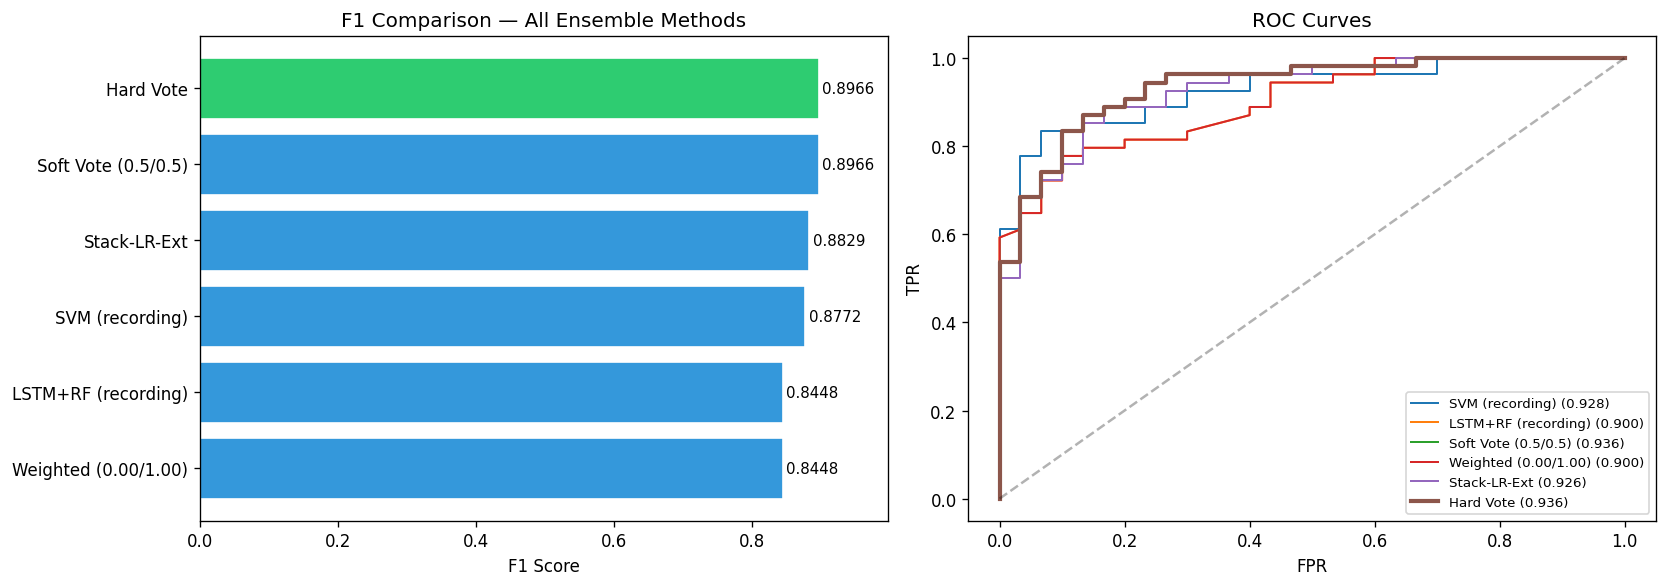

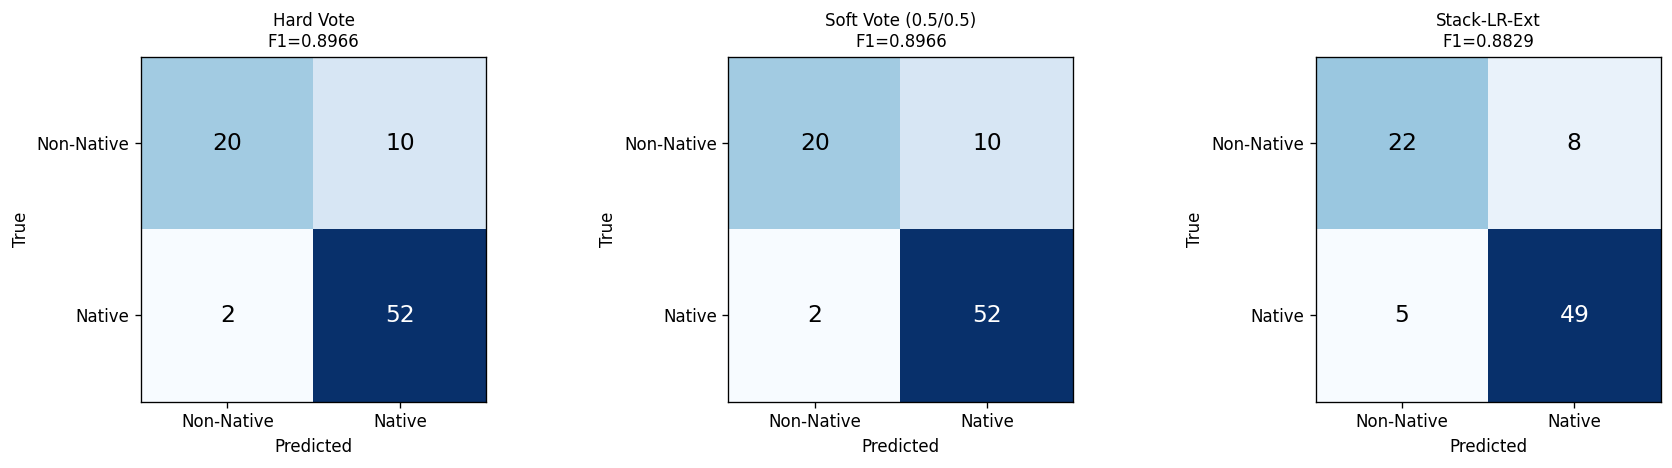


📐 McNemar's Test (best ensemble vs base models):
  Hard Vote vs SVM (recording): chi2=0.17, p=0.6831 → ❌ not significant
  Hard Vote vs LSTM+RF (recording): chi2=4.17, p=0.0412 → ✅ significant

📋 Per-Dialect Breakdown:

  Arabic_AE (n=12):
    SVM                        Acc=1.000  F1=1.000
    RF                         Acc=0.917  F1=0.957
    Hard Vote                  Acc=1.000  F1=1.000

  Arabic_MSA (n=24):
    SVM                        Acc=0.917  F1=0.957
    RF                         Acc=1.000  F1=1.000
    Hard Vote                  Acc=1.000  F1=1.000

  Arabic_QA (n=22):
    SVM                        Acc=0.727  F1=0.769
    RF                         Acc=0.682  F1=0.741
    Hard Vote                  Acc=0.727  F1=0.769

  Arabic_SA (n=26):
    SVM                        Acc=0.769  F1=0.667
    RF                         Acc=0.615  F1=0.444
    Hard Vote                  Acc=0.769  F1=0.667

✅ Evaluation complete. Best: Hard Vote (F1=0.8966)
  Saved: /content/drive/MyDrive

In [18]:
# ============================================================
# CELL 13 — FULL EVALUATION & COMPARISON
#
# FIXES:
#   - Loads results, common_keys, y_common from Drive
#     (via ensemble_results.joblib) — no in-memory dependency
#   - parent_to_dialect reloaded from stage5_manifest.csv
#     directly — no dependency on Cell 9 memory
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/team_databaes"
OUTPUT_DIR   = f"{PROJECT_ROOT}/outputs"
ENSEMBLE_DIR = f"{OUTPUT_DIR}/ensemble"
MANIFEST_S5  = f"{OUTPUT_DIR}/stage5_manifest.csv"

# ── Load all results from Drive ───────────────────────────────
print("Loading ensemble results from Drive...")
res_data    = joblib.load(f"{ENSEMBLE_DIR}/ensemble_results.joblib")
results     = res_data["results"]
y_common    = res_data["y_common"]
common_keys = res_data["common_keys"]
print("✅ Results loaded.")

# Reload dialect lookup from manifest (no Cell 9 dependency)
seg_df_meta       = pd.read_csv(MANIFEST_S5)
parent_to_dialect = (seg_df_meta.drop_duplicates("parent_id")
                     .set_index("parent_id")["dialect"].to_dict())

print("\n📊 Full Evaluation — All Methods Compared")
print("=" * 60)

# ── Summary table ─────────────────────────────────────────────
rows = []
for name, r in results.items():
    try:
        auc = roc_auc_score(y_common, r["prob"])
    except Exception:
        auc = float("nan")
    rows.append({
        "Method":    name,
        "Accuracy":  r["acc"],
        "F1":        r["f1"],
        "Precision": precision_score(y_common, r["pred"], zero_division=0),
        "Recall":    recall_score(y_common, r["pred"], zero_division=0),
        "ROC-AUC":   auc,
    })

summary_df  = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
best_method = summary_df.iloc[0]["Method"]
best_f1     = summary_df.iloc[0]["F1"]

print(summary_df.to_string(index=False, float_format="%.4f"))
print(f"\n🏆 Best method: {best_method} (F1={best_f1:.4f})")

# ── F1 bar chart + ROC curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = summary_df["Method"].tolist()
f1s    = summary_df["F1"].tolist()
colors = ['#2ecc71' if n == best_method else '#3498db' for n in names]

axes[0].barh(names[::-1], f1s[::-1], color=colors[::-1], edgecolor="white")
axes[0].set_xlabel("F1 Score")
axes[0].set_title("F1 Comparison — All Ensemble Methods")
for i, v in enumerate(f1s[::-1]):
    axes[0].text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=9)
axes[0].set_xlim(0, min(1, max(f1s) + 0.1))

for name, r in results.items():
    try:
        fpr, tpr, _ = roc_curve(y_common, r["prob"])
        auc = roc_auc_score(y_common, r["prob"])
        lw  = 2.5 if name == best_method else 1.2
        axes[1].plot(fpr, tpr, label=f"{name} ({auc:.3f})", linewidth=lw)
    except Exception:
        pass
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curves")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(f"{ENSEMBLE_DIR}/ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Confusion matrices for top 3 ──────────────────────────────
top3 = summary_df.head(3)["Method"].tolist()
fig, axes = plt.subplots(1, len(top3), figsize=(5 * len(top3), 4))
if len(top3) == 1:
    axes = [axes]
for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_common, results[name]["pred"])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}\nF1={results[name]['f1']:.4f}", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Non-Native", "Native"])
    ax.set_yticklabels(["Non-Native", "Native"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
plt.tight_layout()
plt.savefig(f"{ENSEMBLE_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── McNemar's test ────────────────────────────────────────────
print("\n📐 McNemar's Test (best ensemble vs base models):")
best_pred = results[best_method]["pred"]
for base_name in ["SVM (recording)", "LSTM+RF (recording)"]:
    if base_name not in results:
        continue
    base_pred = results[base_name]["pred"]
    b = ((best_pred == y_common) & (base_pred != y_common)).sum()
    c = ((best_pred != y_common) & (base_pred == y_common)).sum()
    if b + c > 0:
        chi2  = (abs(b - c) - 1) ** 2 / (b + c)
        p_val = 1 - stats.chi2.cdf(chi2, 1)
    else:
        chi2, p_val = 0.0, 1.0
    sig = "✅ significant" if p_val < 0.05 else "❌ not significant"
    print(f"  {best_method} vs {base_name}: chi2={chi2:.2f}, p={p_val:.4f} → {sig}")

# ── Per-dialect breakdown ─────────────────────────────────────
print("\n📋 Per-Dialect Breakdown:")
test_dialects = [parent_to_dialect.get(k.split("__")[0], "unknown")
                 for k in common_keys]
dialect_df = pd.DataFrame({
    "dialect":   test_dialects,
    "y_true":    y_common,
    "best_pred": best_pred,
    "svm_pred":  results["SVM (recording)"]["pred"],
    "rf_pred":   results["LSTM+RF (recording)"]["pred"],
})

for d in sorted(dialect_df["dialect"].unique()):
    mask = dialect_df["dialect"] == d
    n    = mask.sum()
    if n == 0:
        continue
    yt = dialect_df.loc[mask, "y_true"].values
    print(f"\n  {d} (n={n}):")
    for col, label in [("svm_pred", "SVM"), ("rf_pred", "RF"), ("best_pred", best_method)]:
        yp = dialect_df.loc[mask, col].values
        print(f"    {label:25s}  Acc={accuracy_score(yt, yp):.3f}  "
              f"F1={f1_score(yt, yp, zero_division=0):.3f}")

print(f"\n✅ Evaluation complete. Best: {best_method} (F1={best_f1:.4f})")

# Save summary for Cell 14
summary_df.to_csv(f"{ENSEMBLE_DIR}/ensemble_metrics.csv", index=False)
joblib.dump({"summary_df": summary_df, "best_method": best_method, "best_f1": best_f1},
            f"{ENSEMBLE_DIR}/eval_summary.joblib")
print(f"  Saved: {ENSEMBLE_DIR}/ensemble_metrics.csv")

In [19]:
# ============================================================
# CELL 14 — SAVE ALL OUTPUTS
#
# FIXES:
#   - All models/config loaded from Drive — no in-memory deps
#   - lstm_config loaded from lstm_config.joblib (not memory)
#   - rf_final, lr_meta, gbm_meta loaded from saved joblib files
#   - Fixed HIDDEN_DIM_REPORT default: was 64, correct is 128
#   - best_w, use_pruned, important_mask all loaded from Drive
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/team_databaes"
OUTPUT_DIR   = f"{PROJECT_ROOT}/outputs"
ENSEMBLE_DIR = f"{OUTPUT_DIR}/ensemble"

print("💾 Saving ensemble outputs...")
print("=" * 55)

# ── Load everything from Drive ────────────────────────────────
align    = joblib.load(f"{ENSEMBLE_DIR}/alignment_data.joblib")
res_data = joblib.load(f"{ENSEMBLE_DIR}/ensemble_results.joblib")
eval_sum = joblib.load(f"{ENSEMBLE_DIR}/eval_summary.joblib")
lstm_config = joblib.load(f"{ENSEMBLE_DIR}/lstm_config.joblib")

common_keys    = align["common_keys"]
y_common       = align["y_common"]
svm_ens_prob   = align["svm_ens_prob"]
rf_ens_prob    = align["rf_ens_prob"]
rf_final       = align["rf_final"]
use_pruned     = align["use_pruned"]
important_mask = align["important_mask"]
best_w         = res_data["best_w"]
lr_meta        = res_data["lr_meta"]
gbm_meta       = res_data["gbm_meta"]
results        = res_data["results"]
summary_df     = eval_sum["summary_df"]
best_method    = eval_sum["best_method"]
best_f1        = eval_sum["best_f1"]

svm_model = joblib.load(f"{ENSEMBLE_DIR}/svm_model.joblib")

# Confirm LSTM config values
INPUT_DIM         = lstm_config.get("input_dim", 1030)
HIDDEN_DIM_REPORT = lstm_config.get("hidden_dim", 128)   # FIX: default was 64, correct is 128
NUM_LAYERS        = lstm_config.get("num_layers", 2)

# Data sizes
data         = np.load(f"{OUTPUT_DIR}/stage7_features.npz", allow_pickle=True)
n_train_recs = len(np.unique(align.get("common_train_keys", [])))
n_test_recs  = len(common_keys)

# ── Per-recording predictions CSV ────────────────────────────
pred_df = pd.DataFrame({
    "recording_key":        common_keys,
    "y_true":               y_common,
    "svm_prob":             svm_ens_prob,
    "rf_prob":              rf_ens_prob,
    "best_ensemble_prob":   results[best_method]["prob"],
    "best_ensemble_pred":   results[best_method]["pred"],
    "best_method":          best_method,
})
pred_df.to_csv(f"{ENSEMBLE_DIR}/ensemble_predictions.csv", index=False)
print(f"  ✅ ensemble_predictions.csv  ({len(pred_df)} recordings)")

# ── Full ensemble config (all models + metadata) ─────────────
joblib.dump({
    "svm_model":     svm_model,
    "rf_model":      rf_final,
    "lstm_config":   lstm_config,
    "lr_meta":       lr_meta,
    "gbm_meta":      gbm_meta,
    "best_method":   best_method,
    "best_weight_svm": best_w,
    "use_pruned_rf": use_pruned,
    "important_mask": important_mask,
    "summary":       summary_df.to_dict(),
}, f"{ENSEMBLE_DIR}/ensemble_config.joblib")
print(f"  ✅ ensemble_config.joblib")

# Confirm individual model files exist
for fname in ["lstm_encoder.pt", "svm_model.joblib", "rf_model.joblib",
              "ensemble_metrics.csv", "ensemble_comparison.png",
              "confusion_matrices.png"]:
    path = f"{ENSEMBLE_DIR}/{fname}"
    status = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"  {status} {fname}")

# ── Markdown report ───────────────────────────────────────────
report = f"""# Ensemble Results — Fully Standalone Pipeline

## Best Method: **{best_method}** (F1 = {best_f1:.4f})

## All Results
{summary_df.to_markdown(index=False, floatfmt=".4f")}

## Architecture
- **SVM**: LinearSVC (CalibratedClassifierCV), segment-level
  → aggregated to recording (mean probability over segments)
- **LSTM+RF**: BiLSTM({INPUT_DIM}→{HIDDEN_DIM_REPORT}×2 = {HIDDEN_DIM_REPORT*2}-dim)
  → Random Forest ({rf_final.n_estimators} trees), recording-level
- **Ensemble**: {best_method}

## Data
- Training recordings : {n_train_recs}
- Test recordings     : {n_test_recs}
- Feature dim         : {INPUT_DIM} (1024 wav2vec2-large + 6 prosodic)

## Files Saved
- `ensemble_metrics.csv`       — method comparison table
- `ensemble_predictions.csv`   — per-recording predictions
- `ensemble_config.joblib`     — all trained models + config
- `lstm_encoder.pt`            — BiLSTM encoder weights
- `svm_model.joblib`           — trained LinearSVC
- `rf_model.joblib`            — trained Random Forest
- `ensemble_comparison.png`    — F1 bar chart + ROC curves
- `confusion_matrices.png`     — top-3 confusion matrices
- `lstm_config.joblib`         — LSTM hyperparameters
- `alignment_data.joblib`      — aligned probabilities + indices
- `ensemble_results.joblib`    — all ensemble method outputs
"""

with open(f"{ENSEMBLE_DIR}/ensemble_report.md", "w") as f:
    f.write(report)
print(f"  ✅ ensemble_report.md")

print(f"\n{'=' * 55}")
print(f"  🏆 BEST: {best_method} → F1={best_f1:.4f}")
print(f"  📂 All outputs: {ENSEMBLE_DIR}/")
print(f"{'=' * 55}")
print("\n✅ All done! Pipeline complete.")

💾 Saving ensemble outputs...
  ✅ ensemble_predictions.csv  (84 recordings)
  ✅ ensemble_config.joblib
  ✅ lstm_encoder.pt
  ✅ svm_model.joblib
  ✅ rf_model.joblib
  ✅ ensemble_metrics.csv
  ✅ ensemble_comparison.png
  ✅ confusion_matrices.png
  ✅ ensemble_report.md

  🏆 BEST: Hard Vote → F1=0.8966
  📂 All outputs: /content/drive/MyDrive/team_databaes/outputs/ensemble/

✅ All done! Pipeline complete.
